## 롯데 관중수 데이터 예측 (Ver 5.0 - 2025년 Concept Drift 최적화 버전)

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [2]:
!pip install pytorch-tabnet

In [3]:
from pytorch_tabnet.tab_model import TabNetRegressor
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from korean_font import set_korean_font

# ===== 실행 환경 설정 =====
USE_GPU = False  # GPU 사용: True, CPU 사용: False

DEVICE = "cuda" if USE_GPU and torch.cuda.is_available() else "cpu"
DTYPE = "bfloat16" if DEVICE == "cuda" else "float32"
# ==========================

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12
set_korean_font()

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"사용 디바이스: {DEVICE} (dtype: {DTYPE})")

한글 폰트 설정: AppleGothic
PyTorch version: 2.10.0
CUDA available: False
사용 디바이스: cpu (dtype: float32)


In [4]:
df = pd.read_csv('data/baseball/KBO_2023_2025_FINAL_MASTER_2160.csv',encoding='utf-8-sig')

In [5]:
df.head()

,날짜,경기_시간,상태,홈,방문,홈_점수,방문_점수,승리팀,경기_순번,더블헤더냐,...,관중수,지점명,지점,평균기온(°C),일강수량(mm),평균 풍속(m/s),합계 일사량(MJ/m2),평균 전운량(1/10),연도,평균 상대습도(%)
0,2023-04-01,14:00,정상종료,KT,LG,11,6,KT,1,0,...,18700,수원,119.0,14.7,0.0,1.4,21.67,0.5,2023,47.9
1,2023-04-01,14:00,정상종료,SSG,KIA,4,1,SSG,1,0,...,23000,인천,112.0,15.0,0.0,1.9,21.56,1.3,2023,50.0
2,2023-04-01,14:00,정상종료,두산,롯데,12,10,두산,1,0,...,23750,서울,108.0,17.5,0.0,1.8,21.48,1.8,2023,40.4
3,2023-04-01,14:00,정상종료,삼성,NC,0,8,NC,1,0,...,24000,대구,143.0,15.0,0.0,3.3,22.11,0.9,2023,54.5
4,2023-04-01,14:00,정상종료,키움,한화,3,2,키움,1,0,...,16000,서울,108.0,17.5,0.0,1.8,21.48,1.8,2023,40.4


In [6]:
# 2. 누적 승률 및 순위 계산을 위한 데이터 준비
# 각 팀별로 매일의 승/패/무 기록을 길게 늘어뜨립니다.
matches = []
for _, row in df.iterrows():
    date = row['날짜']
    year = row['연도']
    
    # 홈팀 결과
    home_win = 1 if row['승리팀'] == row['홈'] else 0
    home_loss = 1 if row['승리팀'] == row['방문'] else 0
    home_tie = 1 if row['승리팀'] not in [row['홈'], row['방문']] else 0
    matches.append({'날짜': date, '연도': year, '팀명': row['홈'], '승': home_win, '패': home_loss, '무': home_tie})
    
    # 방문팀 결과
    away_win = 1 if row['승리팀'] == row['방문'] else 0
    away_loss = 1 if row['승리팀'] == row['홈'] else 0
    away_tie = 1 if row['승리팀'] not in [row['홈'], row['방문']] else 0
    matches.append({'날짜': date, '연도': year, '팀명': row['방문'], '승': away_win, '패': away_loss, '무': away_tie})

df_matches = pd.DataFrame(matches)

# 3. 팀별, 연도별 누적 승률 계산
# 날짜별로 정렬한 뒤 누적 합계를 구합니다.
df_matches = df_matches.sort_values(by=['연도', '팀명', '날짜'])
df_matches['누적승'] = df_matches.groupby(['연도', '팀명'])['승'].cumsum()
df_matches['누적패'] = df_matches.groupby(['연도', '팀명'])['패'].cumsum()
df_matches['누적무'] = df_matches.groupby(['연도', '팀명'])['무'].cumsum()

# 승률 = 승 / (승 + 패) (무승부는 계산 제외)
df_matches['승률'] = np.where(
    (df_matches['누적승'] + df_matches['누적패']) > 0,
    df_matches['누적승'] / (df_matches['누적승'] + df_matches['누적패']),
    0
)
# 일간순위 계산: 날짜별로 승률 기준 내림차순 순위
df_matches['일간순위'] = df_matches.groupby('날짜')['승률'].rank(method='min', ascending=False).astype(int)
# 날짜+팀명 기준 중복 제거 (마지막 기록 유지)
df_matches = df_matches.drop_duplicates(subset=['날짜', '팀명'], keep='last')

# 일간순위 계산
df_matches['일간순위'] = df_matches.groupby('날짜')['승률'].rank(method='dense', ascending=False).astype(int)

# 확인
print(f"일간순위 범위: {df_matches['일간순위'].min()} ~ {df_matches['일간순위'].max()}")
print(f"날짜별 팀 수: {df_matches.groupby('날짜')['팀명'].nunique().unique()}")

# daily_rank 변수 생성
daily_rank = df_matches


# 5. 원본 데이터에 '홈팀의 일간 순위' 합치기
df = pd.merge(df, daily_rank[['날짜', '팀명', '일간순위', '승률']], left_on=['날짜', '홈'], right_on=['날짜', '팀명'], how='left')
df = df.rename(columns={'일간순위': '홈팀_일간순위', '승률': '홈팀_승률'}).drop(columns=['팀명'])

# 6. 원본 데이터에 '방문팀의 일간 순위' 합치기
df = pd.merge(df, daily_rank[['날짜', '팀명', '일간순위', '승률']], left_on=['날짜', '방문'], right_on=['날짜', '팀명'], how='left')
df = df.rename(columns={'일간순위': '방문팀_일간순위', '승률': '방문팀_승률'}).drop(columns=['팀명'])

df.head()

일간순위 범위: 1 ~ 10
날짜별 팀 수: [10  8  4  6  2]


,날짜,경기_시간,상태,홈,방문,홈_점수,방문_점수,승리팀,경기_순번,더블헤더냐,...,일강수량(mm),평균 풍속(m/s),합계 일사량(MJ/m2),평균 전운량(1/10),연도,평균 상대습도(%),홈팀_일간순위,홈팀_승률,방문팀_일간순위,방문팀_승률
0,2023-04-01,14:00,정상종료,KT,LG,11,6,KT,1,0,...,0.0,1.4,21.67,0.5,2023,47.9,1,1.0,2,0.0
1,2023-04-01,14:00,정상종료,SSG,KIA,4,1,SSG,1,0,...,0.0,1.9,21.56,1.3,2023,50.0,1,1.0,2,0.0
2,2023-04-01,14:00,정상종료,두산,롯데,12,10,두산,1,0,...,0.0,1.8,21.48,1.8,2023,40.4,1,1.0,2,0.0
3,2023-04-01,14:00,정상종료,삼성,NC,0,8,NC,1,0,...,0.0,3.3,22.11,0.9,2023,54.5,2,0.0,1,1.0
4,2023-04-01,14:00,정상종료,키움,한화,3,2,키움,1,0,...,0.0,1.8,21.48,1.8,2023,40.4,1,1.0,2,0.0


In [7]:
# '홈' 컬럼이 '롯데'인 행만 남기기
df = df[df['홈'] == '롯데'].copy()
df.reset_index(drop=True, inplace=True)

print(f"롯데 홈 경기 수: {len(df)}")
df.head()

롯데 홈 경기 수: 217


,날짜,경기_시간,상태,홈,방문,홈_점수,방문_점수,승리팀,경기_순번,더블헤더냐,...,일강수량(mm),평균 풍속(m/s),합계 일사량(MJ/m2),평균 전운량(1/10),연도,평균 상대습도(%),홈팀_일간순위,홈팀_승률,방문팀_일간순위,방문팀_승률
0,2023-04-07,18:30,정상종료,롯데,KT,1,7,KT,1,0,...,4.4,3.4,23.25,3.5,2023,55.3,6,0.250000,2,0.666667
1,2023-04-08,17:00,정상종료,롯데,KT,3,7,KT,1,0,...,0.0,3.8,26.94,0.8,2023,29.8,8,0.200000,2,0.750000
2,2023-04-09,14:00,정상종료,롯데,KT,5,3,롯데,1,0,...,0.0,4.1,27.73,0.0,2023,38.4,7,0.333333,4,0.600000
3,2023-04-11,18:30,정상종료,롯데,LG,6,5,롯데,1,0,...,0.2,7.8,20.00,6.6,2023,80.5,4,0.428571,2,0.666667
4,2023-04-12,18:30,정상종료,롯데,LG,8,12,LG,1,0,...,0.0,3.6,27.00,1.3,2023,38.3,4,0.375000,2,0.700000


In [8]:
# 구장이 '사직'인 경우만 남기기
df = df[df['구장'] == '사직'].copy()
df.reset_index(drop=True, inplace=True)

print(f"롯데 사직 홈 경기 수: {len(df)}")
df.head()

롯데 사직 홈 경기 수: 205


,날짜,경기_시간,상태,홈,방문,홈_점수,방문_점수,승리팀,경기_순번,더블헤더냐,...,일강수량(mm),평균 풍속(m/s),합계 일사량(MJ/m2),평균 전운량(1/10),연도,평균 상대습도(%),홈팀_일간순위,홈팀_승률,방문팀_일간순위,방문팀_승률
0,2023-04-07,18:30,정상종료,롯데,KT,1,7,KT,1,0,...,4.4,3.4,23.25,3.5,2023,55.3,6,0.250000,2,0.666667
1,2023-04-08,17:00,정상종료,롯데,KT,3,7,KT,1,0,...,0.0,3.8,26.94,0.8,2023,29.8,8,0.200000,2,0.750000
2,2023-04-09,14:00,정상종료,롯데,KT,5,3,롯데,1,0,...,0.0,4.1,27.73,0.0,2023,38.4,7,0.333333,4,0.600000
3,2023-04-11,18:30,정상종료,롯데,LG,6,5,롯데,1,0,...,0.2,7.8,20.00,6.6,2023,80.5,4,0.428571,2,0.666667
4,2023-04-12,18:30,정상종료,롯데,LG,8,12,LG,1,0,...,0.0,3.6,27.00,1.3,2023,38.3,4,0.375000,2,0.700000


In [9]:
# '일강수량(mm)' 컬럼의 NaN 값을 0.0으로 채우기
df['일강수량(mm)'] = df['일강수량(mm)'].fillna(0.0)

# 잘 바뀌었는지 확인 (NaN이 없어졌는지 보세요!)
print("일강수량 결측치 개수:", df['일강수량(mm)'].isnull().sum())
df.head()

일강수량 결측치 개수: 0


,날짜,경기_시간,상태,홈,방문,홈_점수,방문_점수,승리팀,경기_순번,더블헤더냐,...,일강수량(mm),평균 풍속(m/s),합계 일사량(MJ/m2),평균 전운량(1/10),연도,평균 상대습도(%),홈팀_일간순위,홈팀_승률,방문팀_일간순위,방문팀_승률
0,2023-04-07,18:30,정상종료,롯데,KT,1,7,KT,1,0,...,4.4,3.4,23.25,3.5,2023,55.3,6,0.250000,2,0.666667
1,2023-04-08,17:00,정상종료,롯데,KT,3,7,KT,1,0,...,0.0,3.8,26.94,0.8,2023,29.8,8,0.200000,2,0.750000
2,2023-04-09,14:00,정상종료,롯데,KT,5,3,롯데,1,0,...,0.0,4.1,27.73,0.0,2023,38.4,7,0.333333,4,0.600000
3,2023-04-11,18:30,정상종료,롯데,LG,6,5,롯데,1,0,...,0.2,7.8,20.00,6.6,2023,80.5,4,0.428571,2,0.666667
4,2023-04-12,18:30,정상종료,롯데,LG,8,12,LG,1,0,...,0.0,3.6,27.00,1.3,2023,38.3,4,0.375000,2,0.700000


In [10]:
# '날짜' 컬럼을 진짜 날짜 형식으로 변환
df['날짜'] = pd.to_datetime(df['날짜'])

In [11]:
# 1. 내 데이터에서 구장별/연도별 '최대 관중수' 찾기 (날짜에서 연도 즉석 추출)
capacity_df = df.groupby(['구장', df['날짜'].dt.year.rename('연도')])['관중수'].max().reset_index()
capacity_df.rename(columns={'관중수': '시즌최대관중'}, inplace=True)

# 2. 기존 데이터에 병합 (날짜의 연도 정보와 매칭)
df = pd.merge(df, capacity_df, left_on=['구장', df['날짜'].dt.year], right_on=['구장', '연도'], how='left')

# 3. '동원율(%)' 계산 및 불필요한 병합용 컬럼 삭제
df['동원율'] = round((df['관중수'] / df['시즌최대관중']) * 100, 1)
df.drop(columns=['연도', '시즌최대관중', 'key_1'], inplace=True, errors='ignore')

# 4. 확인
print(df[['날짜', '구장', '홈', '방문', '관중수', '동원율']].sort_values(by='동원율', ascending=False).head(5))

            날짜  구장   홈   방문    관중수    동원율
204 2025-09-26  사직  롯데   삼성  22669  100.0
152 2025-05-06  사직  롯데  SSG  22669  100.0
154 2025-05-17  사직  롯데   삼성  22669  100.0
155 2025-05-17  사직  롯데   삼성  22669  100.0
74  2024-04-10  사직  롯데   삼성  22758  100.0


## EDA

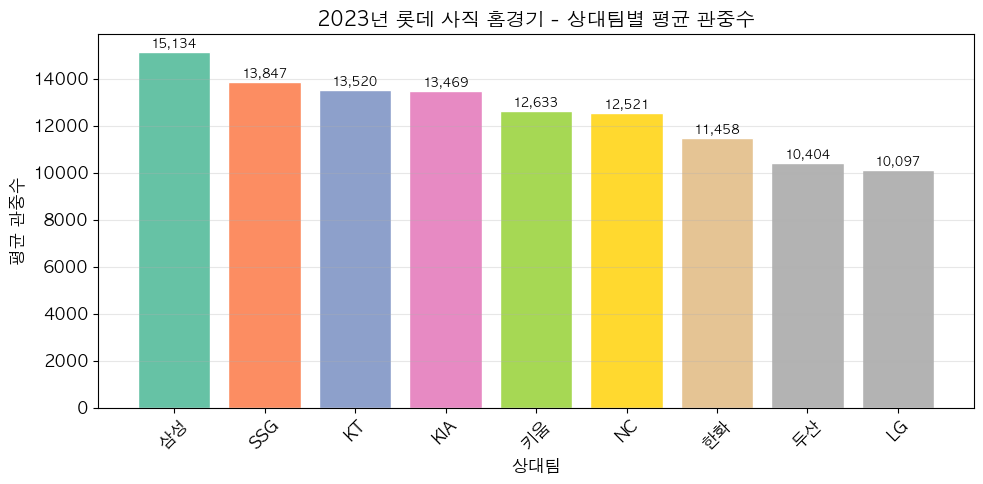

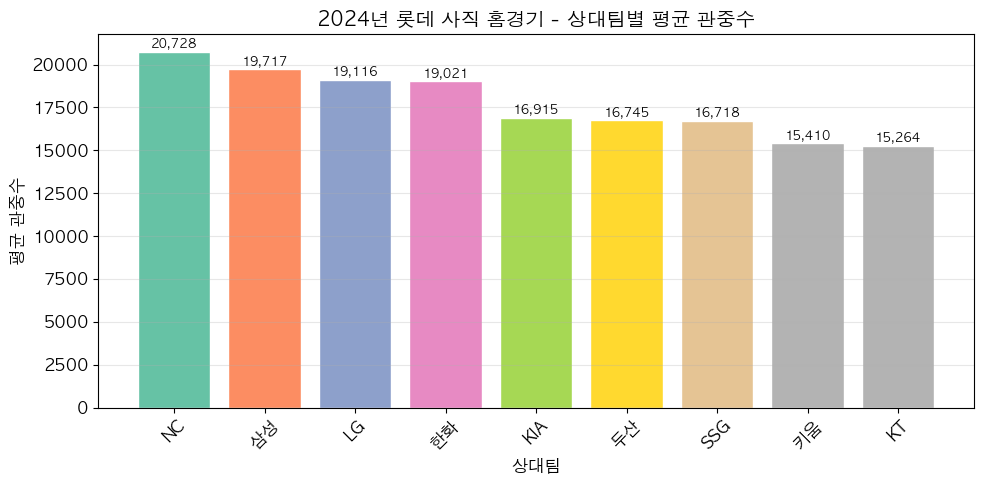

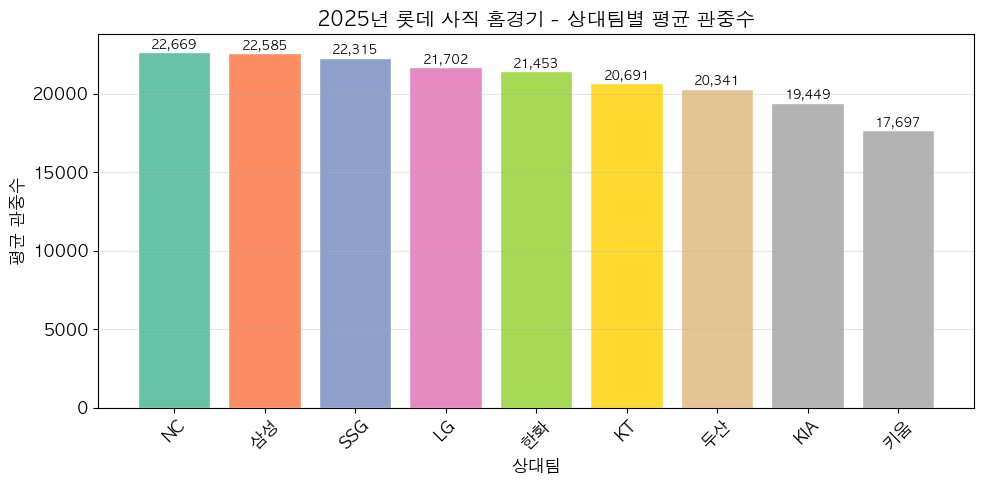

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

if '연도' not in df.columns:
    df['연도'] = pd.to_datetime(df['날짜']).dt.year

years = sorted(df['연도'].unique())

for year in years:
    year_df = df[df['연도'] == year]
    team_avg = year_df.groupby('방문')['관중수'].mean().sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = plt.cm.Set2(np.linspace(0, 1, len(team_avg)))
    bars = ax.bar(team_avg.index, team_avg.values, color=colors, edgecolor='white')
    
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
    
    ax.set_title(f'{year}년 롯데 사직 홈경기 - 상대팀별 평균 관중수', fontsize=14, fontweight='bold')
    ax.set_xlabel('상대팀')
    ax.set_ylabel('평균 관중수')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


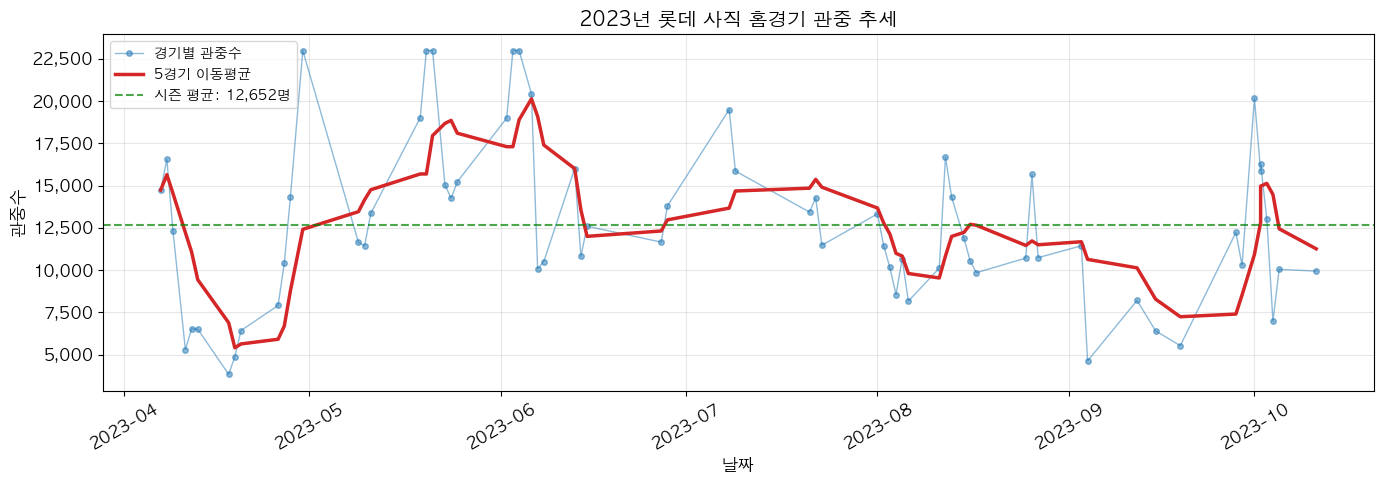

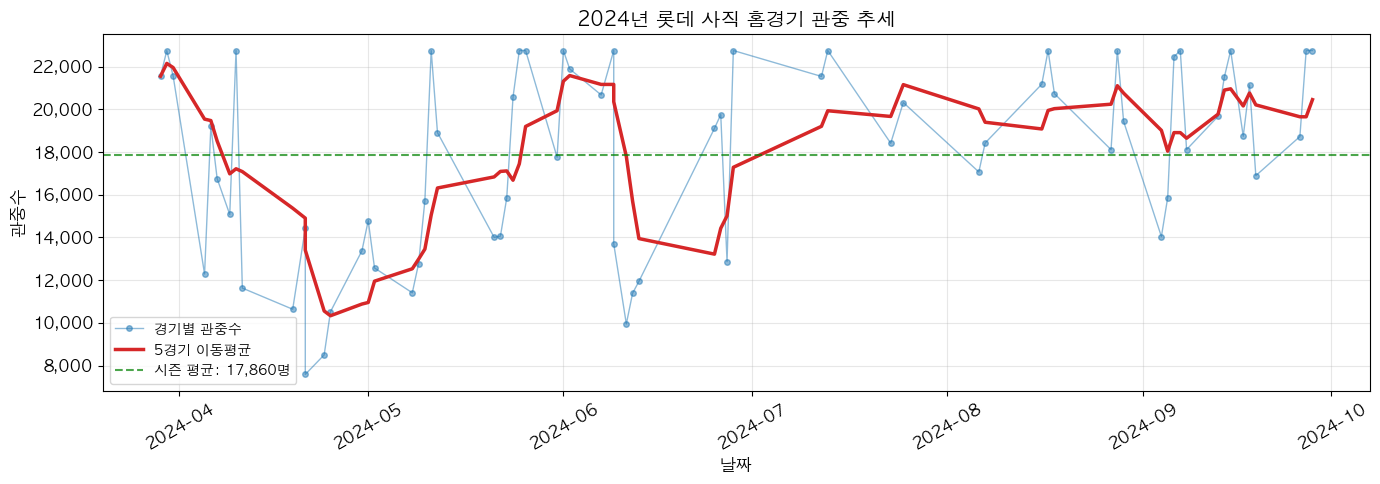

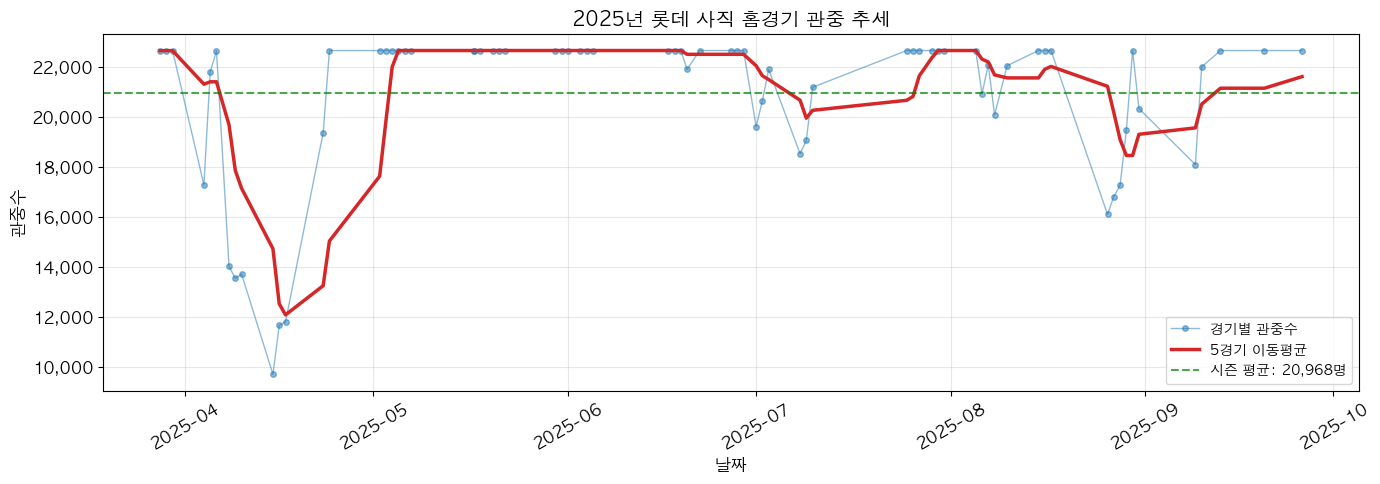

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

if '연도' not in df.columns:
    df['연도'] = pd.to_datetime(df['날짜']).dt.year

df['날짜'] = pd.to_datetime(df['날짜'])
years = sorted(df['연도'].unique())

for year in years:
    year_df = df[df['연도'] == year].sort_values('날짜')
    
    fig, ax = plt.subplots(figsize=(14, 5))
    
    # 실제 관중수 (점 + 선)
    ax.plot(year_df['날짜'], year_df['관중수'], marker='o', markersize=4, 
            color='#1f77b4', alpha=0.5, linewidth=1, label='경기별 관중수')
    
    # 이동평균 추세선 (5경기)
    rolling_avg = year_df['관중수'].rolling(window=5, min_periods=1).mean()
    ax.plot(year_df['날짜'], rolling_avg, color='#d62728', linewidth=2.5, 
            label='5경기 이동평균')
    
    # 시즌 평균선
    season_avg = year_df['관중수'].mean()
    ax.axhline(y=season_avg, color='green', linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'시즌 평균: {season_avg:,.0f}명')
    
    ax.set_title(f'{year}년 롯데 사직 홈경기 관중 추세', fontsize=14, fontweight='bold')
    ax.set_xlabel('날짜')
    ax.set_ylabel('관중수')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()


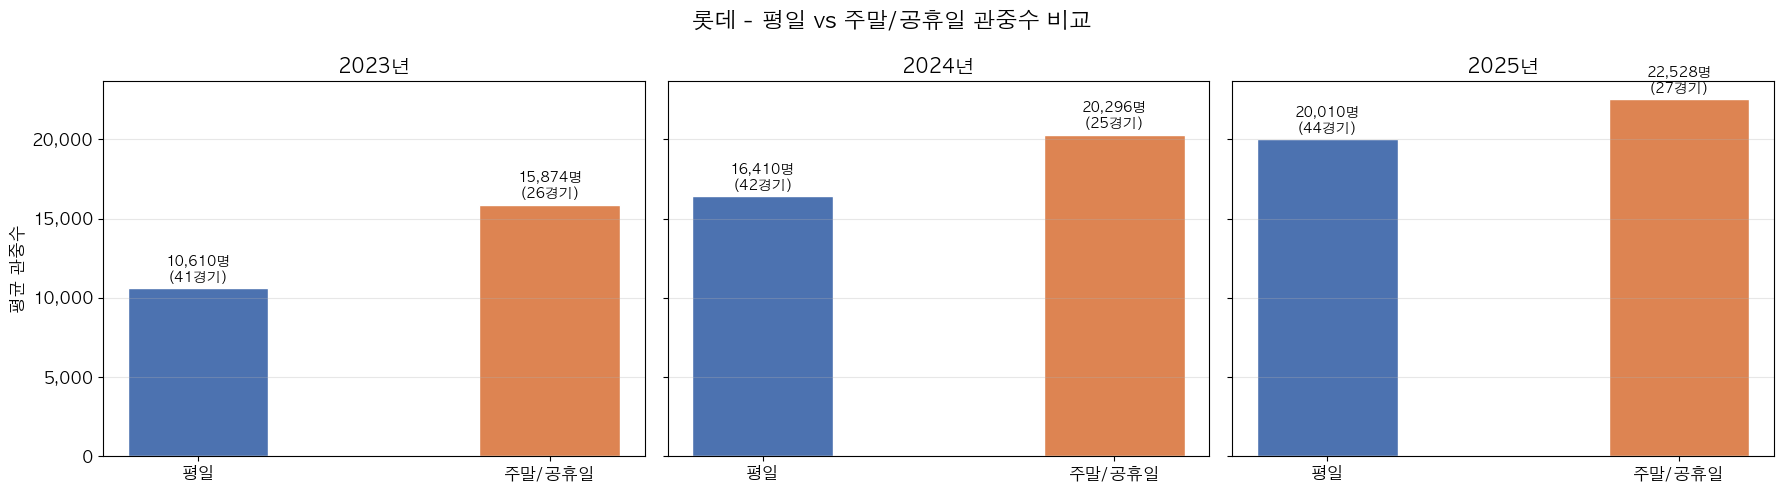

In [14]:
import holidays as hd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 한국 공휴일 목록 생성
kr_holidays = hd.KR(years=[2023, 2024, 2025])

# 🌟 1. df['날짜']를 확실하게 판다스 시간 데이터(Timestamp)로 통일!
df['날짜'] = pd.to_datetime(df['날짜'])

# 구분: 평일 vs 주말/공휴일
def classify_day(row):
    # 🌟 2. row['날짜'].date()를 써서 '순수 날짜' 옷으로 맞춰서 비교!
    # (kr_holidays에 직접 in 연산자를 쓰면 검색도 훨씬 빠릅니다!)
    if row['날짜'].date() in kr_holidays or row['요일'] in ['토', '일']:
        return '주말/공휴일'
    else:
        return '평일'

df['일구분'] = df.apply(classify_day, axis=1)

category_order = ['평일', '주말/공휴일']
colors = {'평일': '#4C72B0', '주말/공휴일': '#DD8452'}

years = sorted(df['연도'].dropna().unique()) # 연도 리스트 안전하게 추출

fig, axes = plt.subplots(1, len(years), figsize=(6 * len(years), 5), sharey=True)
axes = np.atleast_1d(axes)

for ax, year in zip(axes, years):
    year_df = df[df['연도'] == year]
    stats = year_df.groupby('일구분')['관중수'].agg(['mean', 'count']).reindex(category_order).dropna()
    
    bars = ax.bar(stats.index, stats['mean'], color=[colors[c] for c in stats.index],
                  edgecolor='white', width=0.4)
    
    for bar, (cat, row) in zip(bars, stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{row["mean"]:,.0f}명\n({int(row["count"])}경기)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_title(f'{year}년', fontsize=14, fontweight='bold')
    if ax == axes[0]:
        ax.set_ylabel('평균 관중수')
    ax.grid(axis='y', alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('롯데 - 평일 vs 주말/공휴일 관중수 비교', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

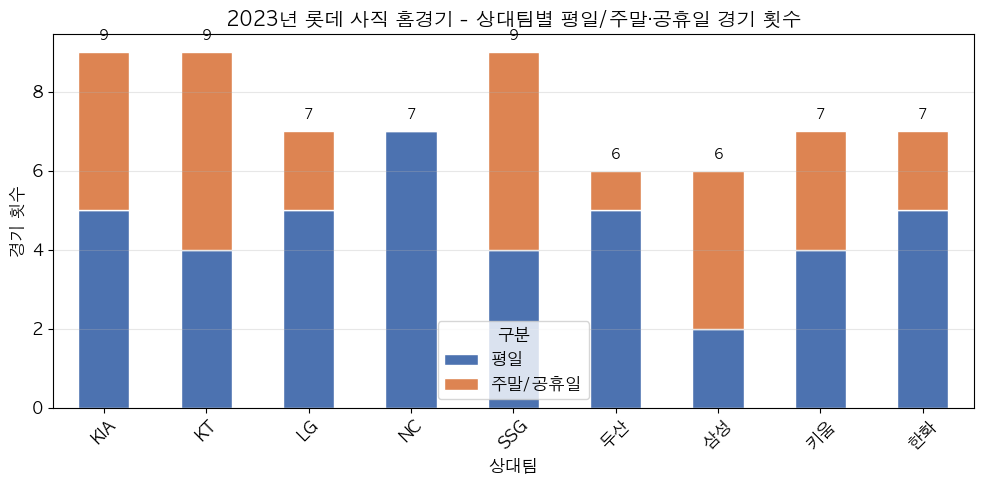

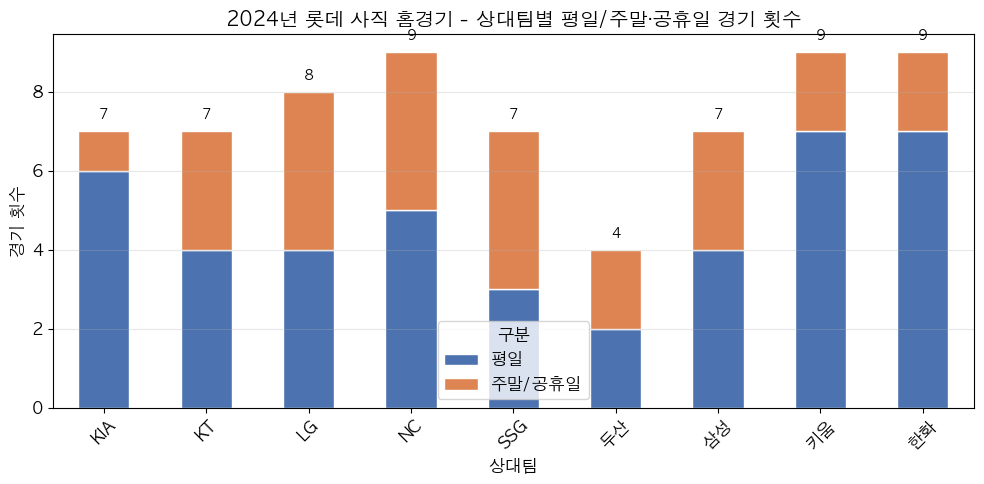

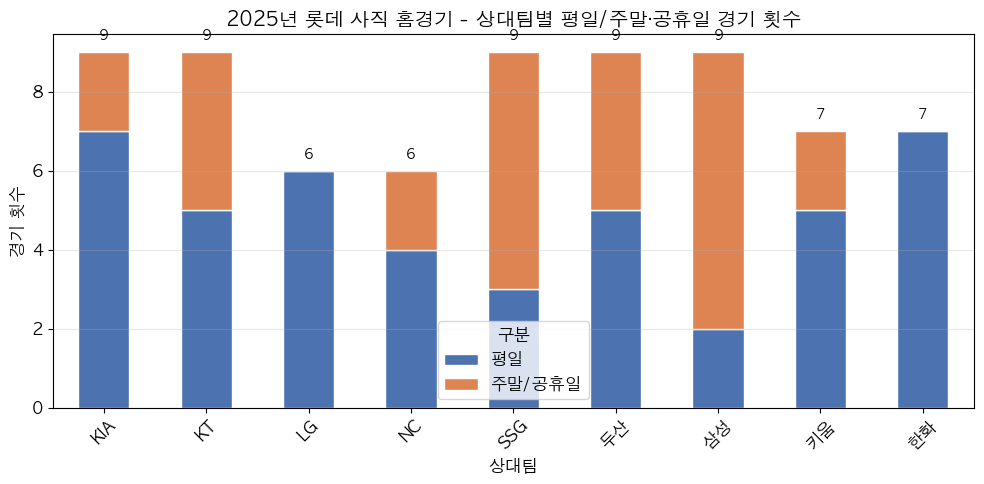

In [15]:
for year in years:
    year_df = df[df['연도'] == year]
    
    ct = pd.crosstab(year_df['방문'], year_df['일구분'])[['평일', '주말/공휴일']]
    ct = ct.sort_index()
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white')
    
    # 막대 위에 합계 표시
    for i, (team, row) in enumerate(ct.iterrows()):
        total = row.sum()
        ax.text(i, total + 0.3, f'{int(total)}', ha='center', fontsize=10, fontweight='bold')
    
    ax.set_title(f'{year}년 롯데 사직 홈경기 - 상대팀별 평일/주말·공휴일 경기 횟수', fontsize=14, fontweight='bold')
    ax.set_xlabel('상대팀')
    ax.set_ylabel('경기 횟수')
    ax.legend(title='구분')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


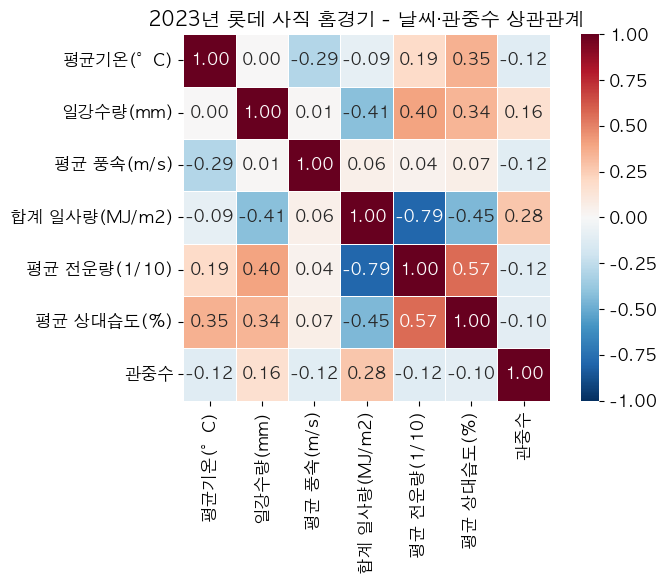

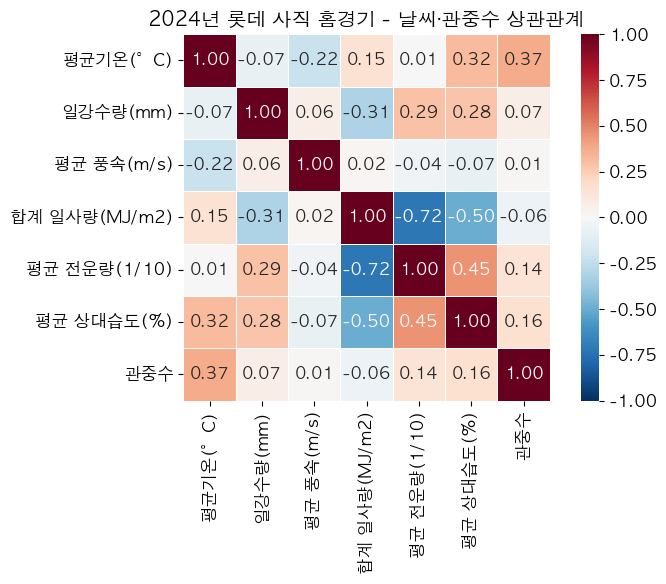

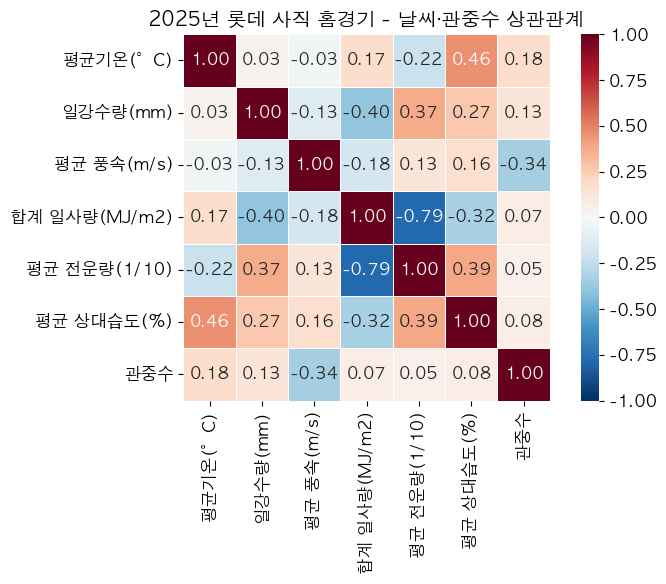

In [16]:
import seaborn as sns

weather_cols = ['평균기온(°C)', '일강수량(mm)', '평균 풍속(m/s)', '합계 일사량(MJ/m2)', '평균 전운량(1/10)','평균 상대습도(%)']

for year in years:
    year_df = df[df['연도'] == year]
    
    corr = year_df[weather_cols + ['관중수']].corr()
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
    ax.set_title(f'{year}년 롯데 사직 홈경기 - 날씨·관중수 상관관계', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


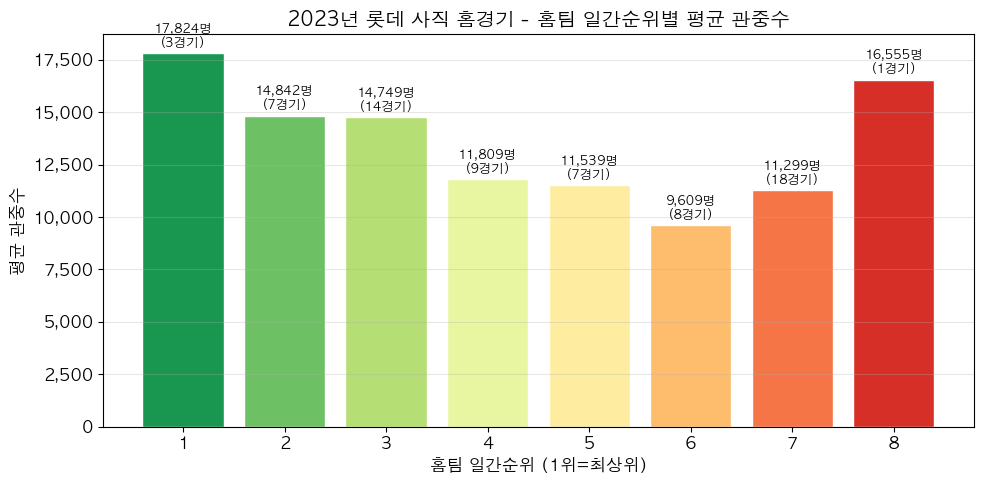

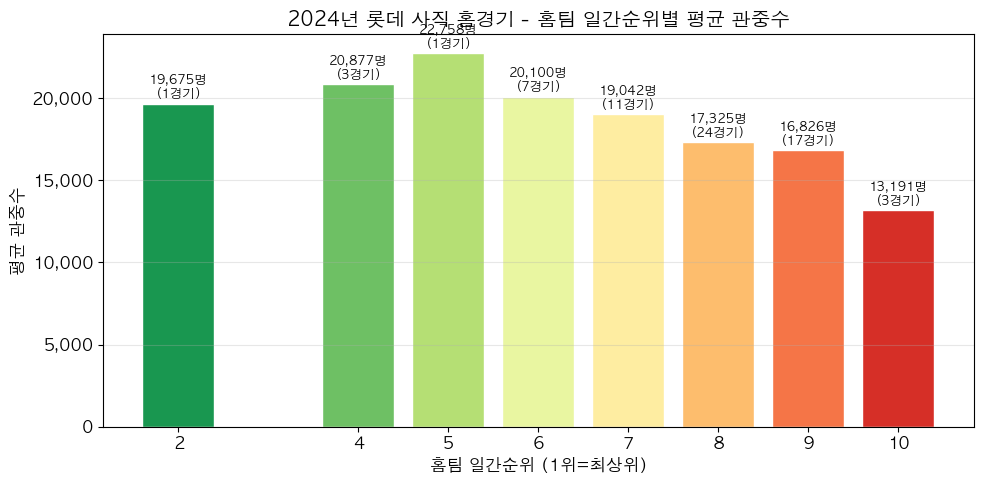

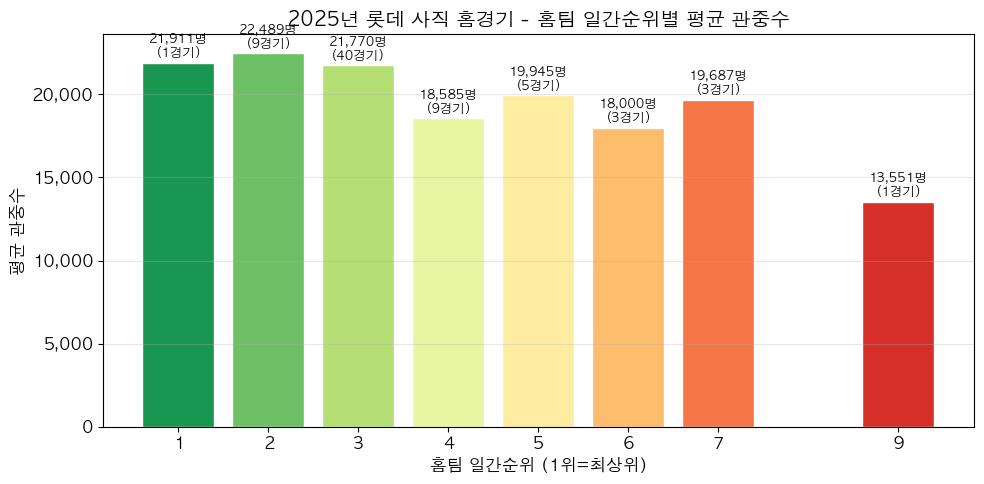

In [17]:
# 홈팀 일간순위가 있는지 확인
rank_col = '홈팀_일간순위' if '홈팀_일간순위' in df.columns else None

if rank_col is None:
    print("⚠️ '홈팀_일간순위' 컬럼이 없습니다. 먼저 일간순위 피처를 생성해주세요.")
else:
    for year in years:
        year_df = df[df['연도'] == year].dropna(subset=[rank_col])
        
        rank_avg = year_df.groupby(rank_col)['관중수'].agg(['mean', 'count']).sort_index()
        
        fig, ax = plt.subplots(figsize=(10, 5))
        bars = ax.bar(rank_avg.index.astype(int), rank_avg['mean'], 
                      color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(rank_avg))),
                      edgecolor='white')
        
        for bar, (rank, row) in zip(bars, rank_avg.iterrows()):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                    f'{row["mean"]:,.0f}명\n({int(row["count"])}경기)',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax.set_title(f'{year}년 롯데 사직 홈경기 - 홈팀 일간순위별 평균 관중수', fontsize=14, fontweight='bold')
        ax.set_xlabel('홈팀 일간순위 (1위=최상위)')
        ax.set_ylabel('평균 관중수')
        ax.set_xticks(rank_avg.index.astype(int))
        ax.grid(axis='y', alpha=0.3)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
        plt.tight_layout()
        plt.show()


연도별 일간순위 추세 그래프 그리기 시작!



/var/folders/3w/7bj38gqs0t58jb31pzzbbybr0000gn/T/ipykernel_8650/4218096943.py:64: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) AppleGothic.
  plt.tight_layout(pad=3.0)
/opt/anaconda3/envs/DL/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


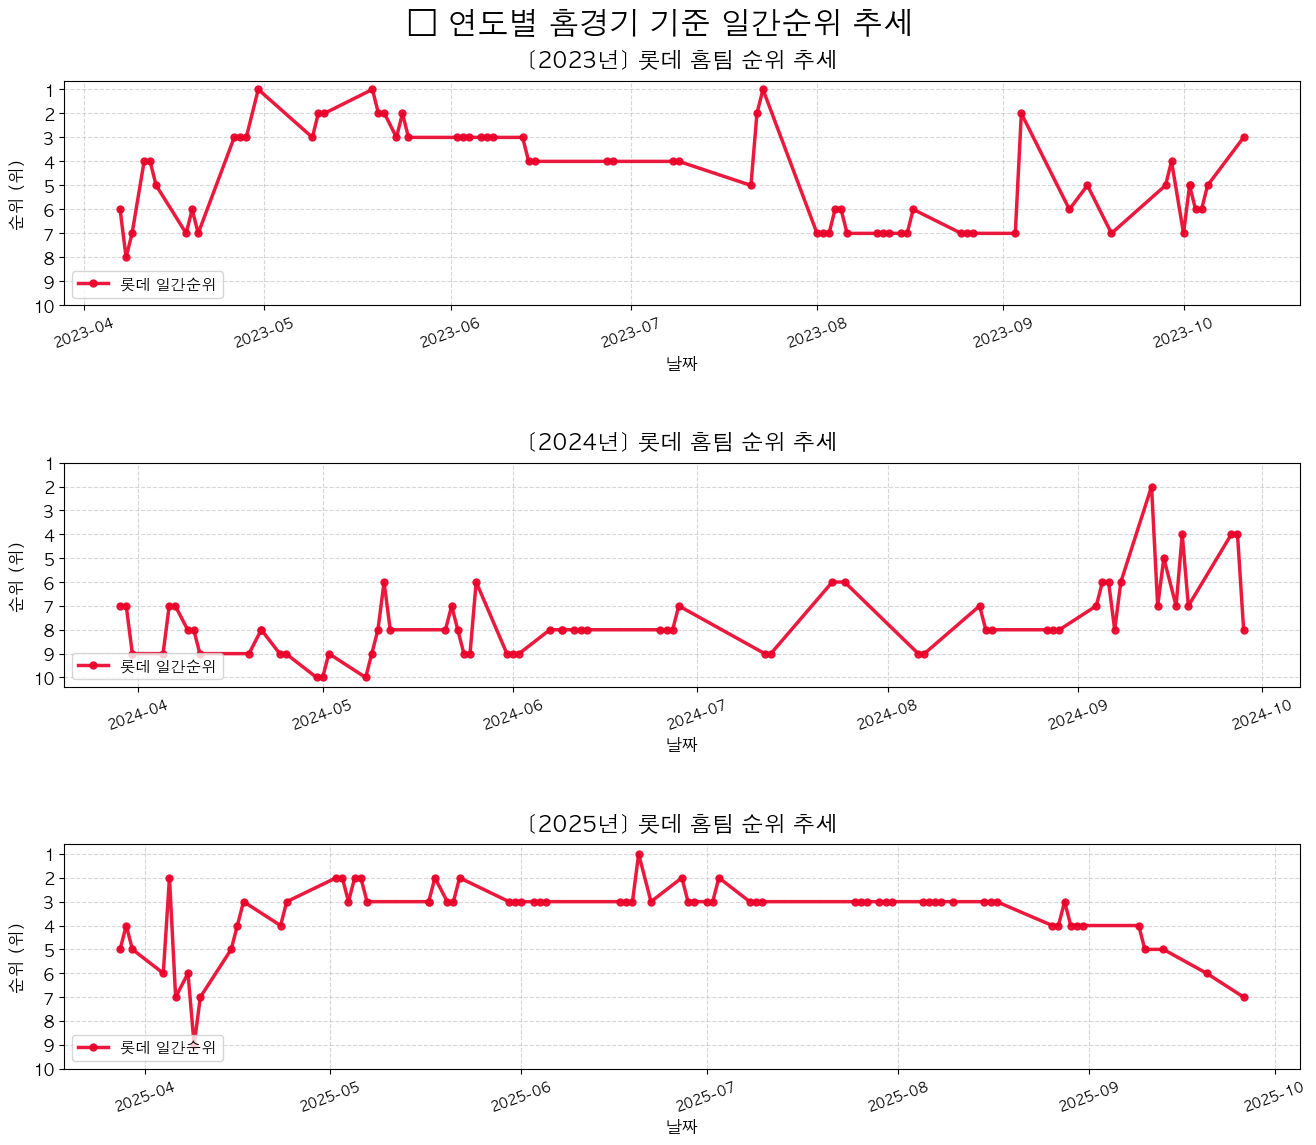

----------------------------------------------------------------------------------------------------
✅ 롯데 순위 추세 그래프 완벽하게 출력 완료!


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("연도별 일간순위 추세 그래프 그리기 시작!\n")

# 1. 데이터 복사 및 안전한 날짜 처리
df_rank = df.copy()

if '날짜' in df_rank.columns:
    df_rank['날짜'] = pd.to_datetime(df_rank['날짜'])
    df_rank = df_rank.sort_values('날짜')

# 2. 연도 파악
year_col = '연도' if '연도' in df_rank.columns else '년도'
years = sorted(df_rank[year_col].dropna().unique())

# 맥 폰트 설정
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False 

# ==============================================================================
# 3. 연도별(Yearly) 서브플롯 생성
# ==============================================================================
fig, axes = plt.subplots(nrows=len(years), ncols=1, figsize=(14, 4 * len(years)))
axes = np.atleast_1d(axes)

fig.suptitle('📈 연도별 홈경기 기준 일간순위 추세', fontsize=22, fontweight='bold', y=0.98)

for i, year in enumerate(years):
    ax = axes[i]
    
    # 해당 연도 데이터 추출
    year_df = df_rank[df_rank[year_col] == year].copy()
    
    # 혹시 모를 결측치 방지
    year_df = year_df.dropna(subset=['홈팀_일간순위'])
    
    if len(year_df) == 0:
        ax.set_title(f'[{year}년] 순위 데이터 없음', fontsize=15, color='gray')
        ax.axis('off')
        continue

    # 🌟상징색(빨강)으로 순위 궤적 그리기!
    ax.plot(year_df['날짜'], year_df['홈팀_일간순위'], 
            color='#EA0029', marker='o', linestyle='-', linewidth=2.5, markersize=5, alpha=0.9,
            label='롯데 일간순위')
    
    # 🌟 핵심 포인트: 순위는 1위가 가장 높으므로 Y축을 뒤집어줍니다!
    ax.invert_yaxis()
    
    # Y축 눈금을 1위부터 10위까지 고정 (KBO는 10개 구단!)
    ax.set_yticks(range(1, 11))
    
    # 서브플롯 꾸미기
    ax.set_title(f'[{year}년] 롯데 홈팀 순위 추세', fontsize=16, fontweight='bold', pad=10)
    ax.set_xlabel('날짜', fontsize=12)
    ax.set_ylabel('순위 (위)', fontsize=12) 
    
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=11, loc='lower left') # 1위가 위로 가므로 범례는 방해 안 되게 아래로!
    ax.tick_params(axis='x', rotation=20, labelsize=10)

plt.tight_layout(pad=3.0)
fig.subplots_adjust(top=0.92) 
plt.show()

print("-" * 100)
print("✅ 롯데 순위 추세 그래프 완벽하게 출력 완료!")

In [19]:
# 사직 구장 최대 수용인원 기준 (약 21,500명)
FULL_CAPACITY = 23000
MAX_CAPACITY = FULL_CAPACITY

for year in years:
    year_df = df[df['연도'] == year].copy()
    
    # 만원 경기 (최대 수용인원의 95% 이상)
    full_games = year_df.nlargest(15, '관중수')
    # 관중수 최하위 15경기
    low_games = year_df.nsmallest(15, '관중수')
    
    print(f"\n{'='*80}")
    print(f"📊 {year}년 시즌 분석")
    print(f"{'='*80}")
    
    # --- 만원 경기 특징 ---
    print(f"\n🔴 만원 경기 ({len(full_games)}경기)")
    if len(full_games) > 0:
        print(f"  ▸ 요일 분포: {dict(full_games['요일'].value_counts())}")
        print(f"  ▸ 평일/주말: {dict(full_games['일구분'].value_counts())}")
        print(f"  ▸ 상대팀:    {dict(full_games['방문'].value_counts())}")
        print(f"  ▸ 평균기온:  {full_games['평균기온(°C)'].mean():.1f}°C")
        print(f"  ▸ 평균강수:  {full_games['일강수량(mm)'].mean():.1f}mm")
        if '홈팀_일간순위' in full_games.columns:
            print(f"  ▸ 홈팀 평균순위: {full_games['홈팀_일간순위'].mean():.1f}위")
        print(f"\n  [경기 목록]")
        display_cols = ['날짜', '방문', '요일', '일구분', '관중수', '평균기온(°C)', '일강수량(mm)']
        if '홈팀_일간순위' in full_games.columns:
            display_cols += ['홈팀_일간순위']
        display(full_games[display_cols].reset_index(drop=True))
    else:
        print("  → 만원 경기 없음")
    
    # --- 최하위 15경기 특징 ---
    print(f"\n🔵 관중수 최하위 15경기")
    print(f"  ▸ 요일 분포: {dict(low_games['요일'].value_counts())}")
    print(f"  ▸ 평일/주말: {dict(low_games['일구분'].value_counts())}")
    print(f"  ▸ 상대팀:    {dict(low_games['방문'].value_counts())}")
    print(f"  ▸ 평균기온:  {low_games['평균기온(°C)'].mean():.1f}°C")
    print(f"  ▸ 평균강수:  {low_games['일강수량(mm)'].mean():.1f}mm")
    if '홈팀_일간순위' in low_games.columns:
        print(f"  ▸ 홈팀 평균순위: {low_games['홈팀_일간순위'].mean():.1f}위")
    print(f"\n  [경기 목록]")
    display(low_games[display_cols].reset_index(drop=True))



📊 2023년 시즌 분석

🔴 만원 경기 (15경기)
  ▸ 요일 분포: {'토': np.int64(5), '일': np.int64(4), '화': np.int64(2), '금': np.int64(2), '월': np.int64(2)}
  ▸ 평일/주말: {'주말/공휴일': np.int64(12), '평일': np.int64(3)}
  ▸ 상대팀:    {'KIA': np.int64(4), 'SSG': np.int64(3), '삼성': np.int64(3), 'KT': np.int64(2), '키움': np.int64(1), 'LG': np.int64(1), '한화': np.int64(1)}
  ▸ 평균기온:  20.3°C
  ▸ 평균강수:  2.3mm
  ▸ 홈팀 평균순위: 3.8위

  [경기 목록]


,날짜,방문,요일,일구분,관중수,평균기온(°C),일강수량(mm),홈팀_일간순위
0,2023-04-30,키움,일,주말/공휴일,22990,15.1,0.0,1
1,2023-05-20,SSG,토,주말/공휴일,22990,18.4,0.0,2
2,2023-05-21,SSG,일,주말/공휴일,22990,19.5,0.0,2
3,2023-06-03,KIA,토,주말/공휴일,22990,21.4,0.0,3
4,2023-06-04,KIA,일,주말/공휴일,22990,23.1,0.0,3
5,2023-06-06,KT,화,주말/공휴일,20441,20.4,0.0,3
6,2023-10-01,삼성,일,주말/공휴일,20159,21.0,0.0,7
7,2023-07-08,LG,토,주말/공휴일,19496,22.2,28.1,4
8,2023-05-19,SSG,금,평일,19011,17.9,4.6,1
9,2023-06-02,KIA,금,평일,18996,23.0,1.9,3



🔵 관중수 최하위 15경기
  ▸ 요일 분포: {'화': np.int64(4), '수': np.int64(4), '목': np.int64(3), '금': np.int64(2), '월': np.int64(1), '일': np.int64(1)}
  ▸ 평일/주말: {'평일': np.int64(14), '주말/공휴일': np.int64(1)}
  ▸ 상대팀:    {'LG': np.int64(4), 'KIA': np.int64(3), 'SSG': np.int64(3), '키움': np.int64(2), '두산': np.int64(1), '한화': np.int64(1), 'NC': np.int64(1)}
  ▸ 평균기온:  21.7°C
  ▸ 평균강수:  0.2mm
  ▸ 홈팀 평균순위: 5.4위

  [경기 목록]


,날짜,방문,요일,일구분,관중수,평균기온(°C),일강수량(mm),홈팀_일간순위
0,2023-04-18,KIA,화,평일,3829,16.8,0.1,7
1,2023-09-04,두산,월,평일,4621,27.1,0.0,2
2,2023-04-19,KIA,수,평일,4869,17.0,0.3,6
3,2023-04-11,LG,화,평일,5286,16.7,0.2,4
4,2023-09-19,키움,화,평일,5523,25.6,0.0,7
5,2023-09-15,키움,금,평일,6409,24.7,2.2,5
6,2023-04-20,KIA,목,평일,6423,20.0,0.0,7
7,2023-04-13,LG,목,평일,6505,15.4,0.0,5
8,2023-04-12,LG,수,평일,6519,15.1,0.0,4
9,2023-10-04,LG,수,평일,6970,21.2,0.0,6



📊 2024년 시즌 분석

🔴 만원 경기 (15경기)
  ▸ 요일 분포: {'토': np.int64(8), '일': np.int64(3), '수': np.int64(2), '금': np.int64(2)}
  ▸ 평일/주말: {'주말/공휴일': np.int64(12), '평일': np.int64(3)}
  ▸ 상대팀:    {'삼성': np.int64(3), 'NC': np.int64(3), '한화': np.int64(3), 'SSG': np.int64(2), 'LG': np.int64(1), 'KT': np.int64(1), '키움': np.int64(1), 'KIA': np.int64(1)}
  ▸ 평균기온:  22.4°C
  ▸ 평균강수:  1.3mm
  ▸ 홈팀 평균순위: 7.3위

  [경기 목록]


...

,날짜,방문,요일,일구분,관중수,평균기온(°C),일강수량(mm),홈팀_일간순위
0,2024-04-21,KT,일,주말/공휴일,7582,15.8,2.1,8
1,2024-04-24,SSG,수,평일,8499,15.2,0.0,9
2,2024-06-11,키움,화,평일,9948,22.7,0.0,8
3,2024-04-25,SSG,목,평일,10518,17.1,0.0,9
4,2024-04-19,KT,금,평일,10636,17.9,0.0,9
5,2024-06-12,키움,수,평일,11390,23.8,0.0,8
6,2024-05-08,한화,수,평일,11407,13.4,0.0,10
7,2024-04-11,삼성,목,평일,11628,14.6,0.0,9
8,2024-06-13,키움,목,평일,11941,24.9,0.0,8
9,2024-04-05,두산,금,평일,12289,13.5,0.0,9



📊 2025년 시즌 분석

🔴 만원 경기 (15경기)
  ▸ 요일 분포: {'토': np.int64(4), '목': np.int64(2), '금': np.int64(2), '일': np.int64(2), '화': np.int64(2), '수': np.int64(2), '월': np.int64(1)}
  ▸ 평일/주말: {'주말/공휴일': np.int64(8), '평일': np.int64(7)}
  ▸ 상대팀:    {'SSG': np.int64(5), 'NC': np.int64(3), '삼성': np.int64(3), 'LG': np.int64(3), '한화': np.int64(1)}
  ▸ 평균기온:  17.3°C
  ▸ 평균강수:  0.8mm
  ▸ 홈팀 평균순위: 2.6위

  [경기 목록]


,날짜,방문,요일,일구분,관중수,평균기온(°C),일강수량(mm),홈팀_일간순위
0,2025-04-24,한화,목,평일,22669,15.5,0.0,3
1,2025-05-02,NC,금,평일,22669,16.1,0.0,2
2,2025-05-03,NC,토,주말/공휴일,22669,14.2,2.4,2
3,2025-05-04,NC,일,주말/공휴일,22669,15.2,0.0,3
4,2025-05-05,SSG,월,주말/공휴일,22669,15.3,3.0,2
5,2025-05-06,SSG,화,주말/공휴일,22669,13.3,5.5,2
6,2025-05-07,SSG,수,평일,22669,14.5,0.0,3
7,2025-05-17,삼성,토,주말/공휴일,22669,18.6,0.6,3
8,2025-05-17,삼성,토,주말/공휴일,22669,18.6,0.6,3
9,2025-05-18,삼성,일,주말/공휴일,22669,18.1,0.0,2



🔵 관중수 최하위 15경기
  ▸ 요일 분포: {'화': np.int64(5), '수': np.int64(5), '목': np.int64(3), '금': np.int64(2)}
  ▸ 평일/주말: {'평일': np.int64(15)}
  ▸ 상대팀:    {'두산': np.int64(4), '키움': np.int64(3), 'KIA': np.int64(3), 'KT': np.int64(3), '한화': np.int64(2)}
  ▸ 평균기온:  20.7°C
  ▸ 평균강수:  0.1mm
  ▸ 홈팀 평균순위: 4.6위

  [경기 목록]


,날짜,방문,요일,일구분,관중수,평균기온(°C),일강수량(mm),홈팀_일간순위
0,2025-04-15,키움,화,평일,9714,10.9,0.0,5
1,2025-04-16,키움,수,평일,11679,14.4,0.0,4
2,2025-04-17,키움,목,평일,11812,16.9,0.0,3
3,2025-04-09,KIA,수,평일,13551,14.3,0.0,9
4,2025-04-10,KIA,목,평일,13726,15.4,0.0,7
5,2025-04-08,KIA,화,평일,14038,15.8,0.0,6
6,2025-08-26,KT,화,평일,16116,29.0,0.0,4
7,2025-08-27,KT,수,평일,16826,28.7,0.0,4
8,2025-08-28,KT,목,평일,17273,28.6,0.0,3
9,2025-04-04,두산,금,평일,17293,10.8,0.0,6


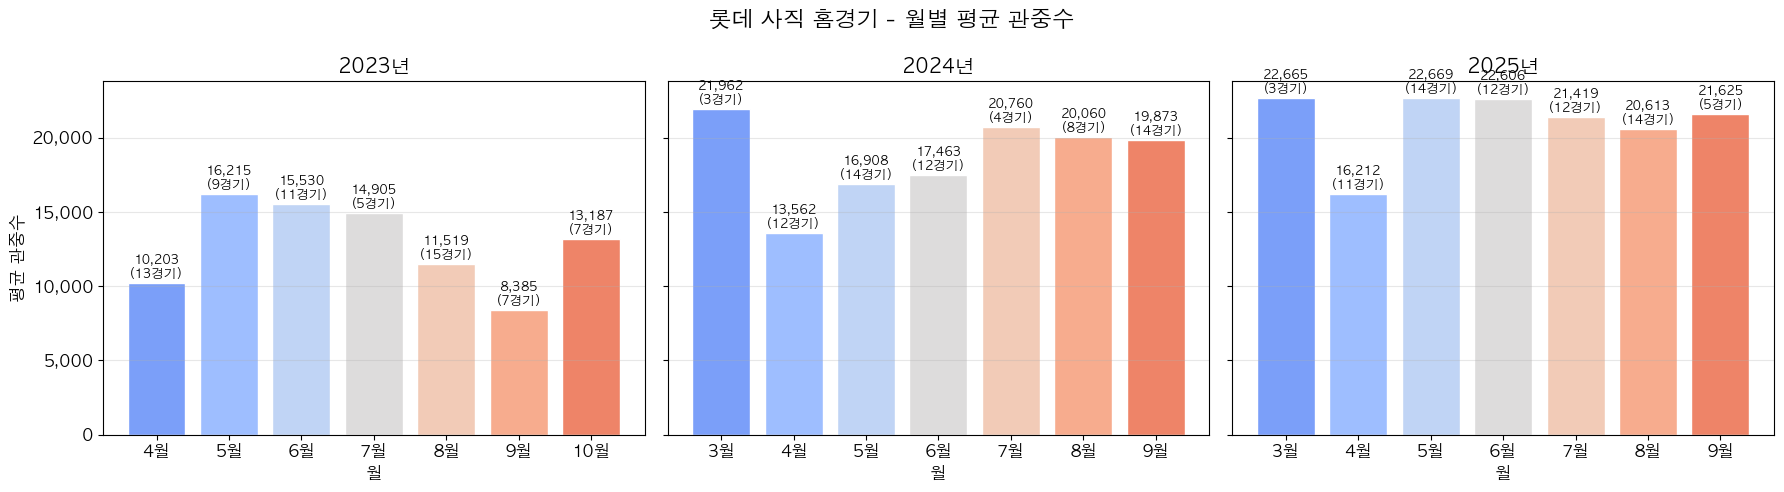

/var/folders/3w/7bj38gqs0t58jb31pzzbbybr0000gn/T/ipykernel_8650/136781778.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_year, labels=[f'{y}년' for y in years], patch_artist=True,


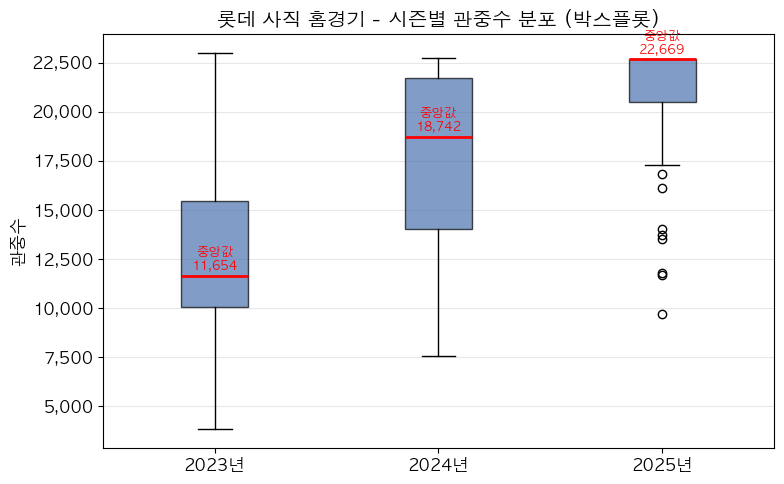

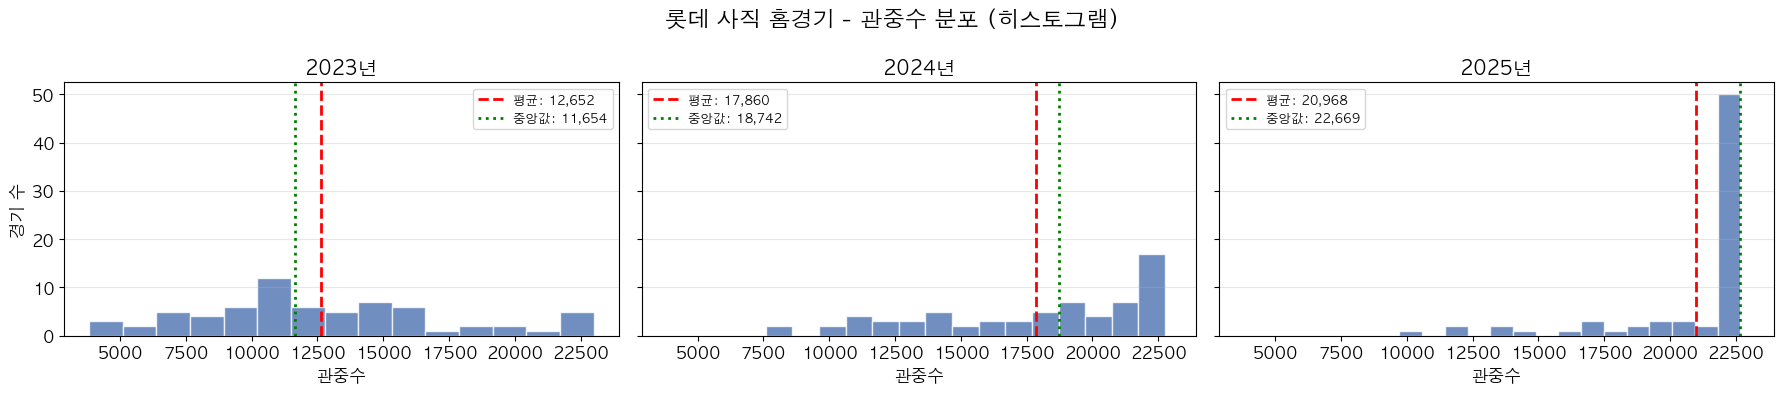

In [20]:
# ========================================
# 1. 월별 관중수 추이
# ========================================
if '월' not in df.columns:
    df['월'] = pd.to_datetime(df['날짜']).dt.month

fig, axes = plt.subplots(1, len(years), figsize=(6 * len(years), 5), sharey=True)
axes = np.atleast_1d(axes)

for ax, year in zip(axes, years):
    year_df = df[df['연도'] == year]
    monthly = year_df.groupby('월')['관중수'].agg(['mean', 'count'])
    
    bars = ax.bar(monthly.index, monthly['mean'], color=plt.cm.coolwarm(np.linspace(0.2, 0.8, len(monthly))),
                  edgecolor='white')
    
    for bar, (m, row) in zip(bars, monthly.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{row["mean"]:,.0f}\n({int(row["count"])}경기)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_title(f'{year}년', fontsize=14, fontweight='bold')
    ax.set_xlabel('월')
    ax.set_xticks(monthly.index)
    ax.set_xticklabels([f'{int(m)}월' for m in monthly.index])
    if ax == axes[0]:
        ax.set_ylabel('평균 관중수')
    ax.grid(axis='y', alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('롯데 사직 홈경기 - 월별 평균 관중수', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ========================================
# 4. 관중수 분포 (박스플롯 + 히스토그램)
# ========================================

# 4-1. 시즌별 박스플롯
fig, ax = plt.subplots(figsize=(8, 5))
data_by_year = [df[df['연도'] == y]['관중수'].values for y in years]
bp = ax.boxplot(data_by_year, labels=[f'{y}년' for y in years], patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))

for i, year in enumerate(years):
    year_data = df[df['연도'] == year]['관중수']
    ax.text(i + 1, year_data.median() + 300, f'중앙값\n{year_data.median():,.0f}',
            ha='center', fontsize=9, fontweight='bold', color='red')

ax.set_title('롯데 사직 홈경기 - 시즌별 관중수 분포 (박스플롯)', fontsize=14, fontweight='bold')
ax.set_ylabel('관중수')
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

# 4-2. 시즌별 히스토그램
fig, axes = plt.subplots(1, len(years), figsize=(6 * len(years), 4), sharey=True, sharex=True)
axes = np.atleast_1d(axes)

for ax, year in zip(axes, years):
    year_data = df[df['연도'] == year]['관중수']
    ax.hist(year_data, bins=15, color='#4C72B0', edgecolor='white', alpha=0.8)
    ax.axvline(year_data.mean(), color='red', linestyle='--', linewidth=2, label=f'평균: {year_data.mean():,.0f}')
    ax.axvline(year_data.median(), color='green', linestyle=':', linewidth=2, label=f'중앙값: {year_data.median():,.0f}')
    ax.set_title(f'{year}년', fontsize=14, fontweight='bold')
    ax.set_xlabel('관중수')
    if ax == axes[0]:
        ax.set_ylabel('경기 수')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('롯데 사직 홈경기 - 관중수 분포 (히스토그램)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


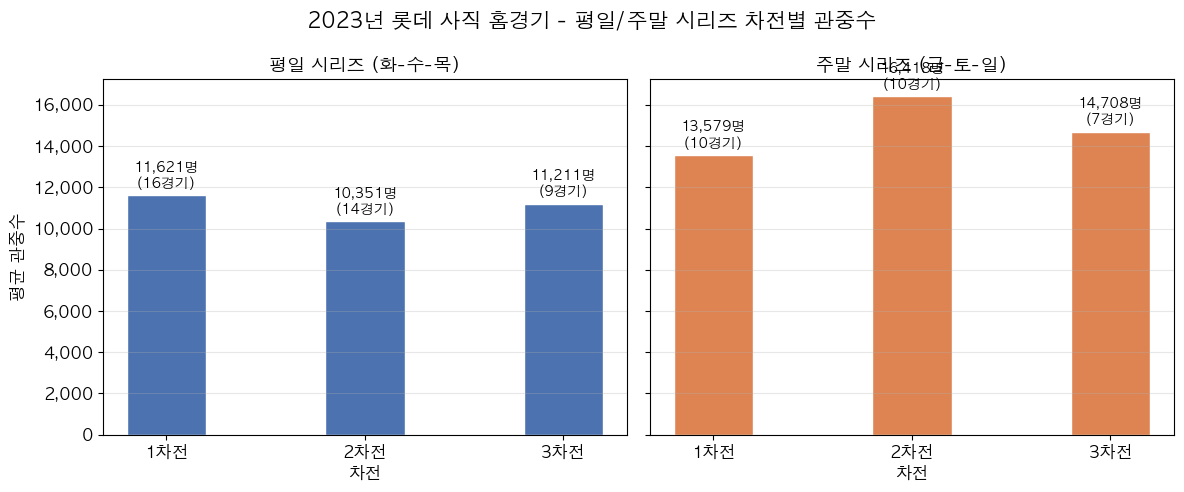

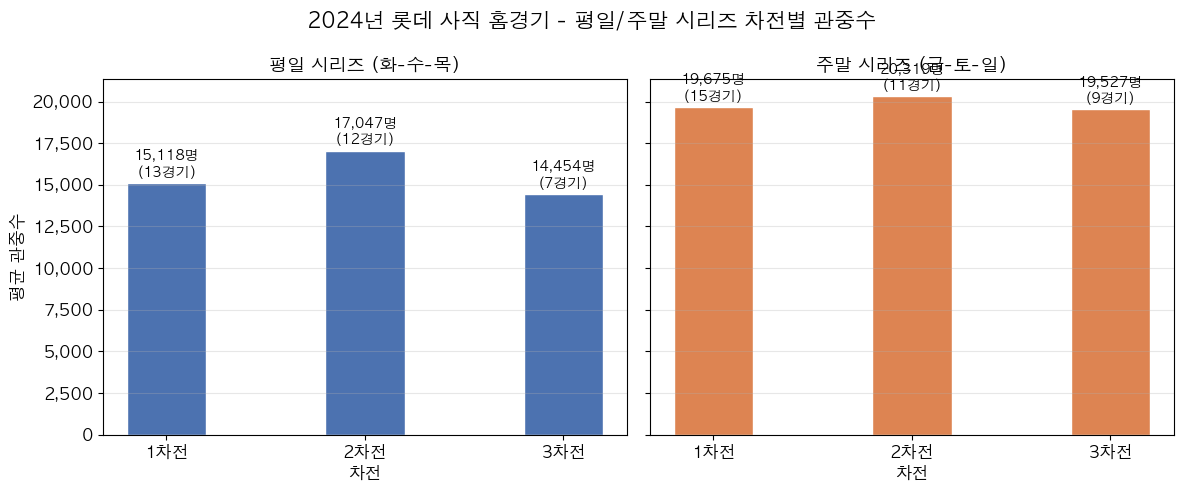

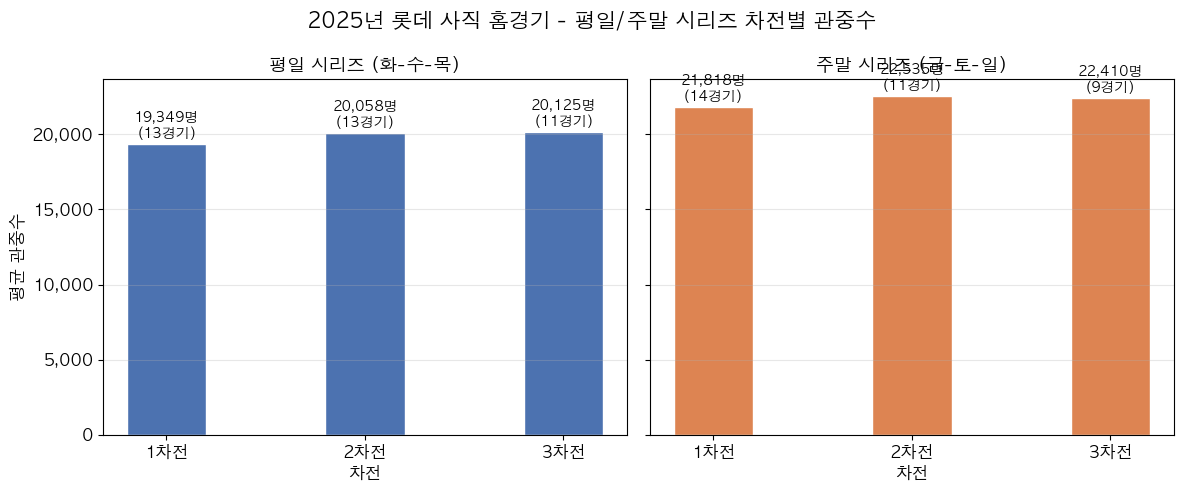

In [21]:
# ========================================
# 평일 시리즈 vs 주말 시리즈 차전별 관중수
# ========================================
df_sorted = df.sort_values('날짜').copy()
df_sorted['상대변경'] = (df_sorted['방문'] != df_sorted['방문'].shift(1)).astype(int)
df_sorted['시리즈ID'] = df_sorted['상대변경'].cumsum()
df_sorted['시리즈_차전'] = df_sorted.groupby('시리즈ID').cumcount() + 1

# 시리즈의 첫 경기 요일로 평일/주말 시리즈 구분
series_start_day = df_sorted.groupby('시리즈ID')['요일'].first()
weekend_series = series_start_day[series_start_day.isin(['금', '토'])].index
weekday_series = series_start_day[~series_start_day.isin(['금', '토', '일'])].index

df_sorted['시리즈구분'] = df_sorted['시리즈ID'].apply(
    lambda x: '주말 시리즈 (금-토-일)' if x in weekend_series else '평일 시리즈 (화-수-목)')

df_series = df_sorted[df_sorted['시리즈_차전'] <= 3]

for year in years:
    year_df = df_series[df_series['연도'] == year]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    
    for ax, stype in zip(axes, ['평일 시리즈 (화-수-목)', '주말 시리즈 (금-토-일)']):
        sub = year_df[year_df['시리즈구분'] == stype]
        avg = sub.groupby('시리즈_차전')['관중수'].agg(['mean', 'count'])
        
        color = '#4C72B0' if '평일' in stype else '#DD8452'
        bars = ax.bar(avg.index, avg['mean'], color=color, edgecolor='white', width=0.4)
        
        for bar, (g, row) in zip(bars, avg.iterrows()):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                    f'{row["mean"]:,.0f}명\n({int(row["count"])}경기)',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        ax.set_title(stype, fontsize=13, fontweight='bold')
        ax.set_xlabel('차전')
        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels(['1차전', '2차전', '3차전'])
        if ax == axes[0]:
            ax.set_ylabel('평균 관중수')
        ax.grid(axis='y', alpha=0.3)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    
    plt.suptitle(f'{year}년 롯데 사직 홈경기 - 평일/주말 시리즈 차전별 관중수', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [22]:
print(f"총 컬럼 수: {len(df.columns)}개\n")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")


총 컬럼 수: 32개

   1. 날짜
   2. 경기_시간
   3. 상태
   4. 홈
   5. 방문
   6. 홈_점수
   7. 방문_점수
   8. 승리팀
   9. 경기_순번
  10. 더블헤더냐
  11. 실제_진행_순번
  12. 요일
  13. 구장
  14. 관중수
  15. 지점명
  16. 지점
  17. 평균기온(°C)
  18. 일강수량(mm)
  19. 평균 풍속(m/s)
  20. 합계 일사량(MJ/m2)
  21. 평균 전운량(1/10)
  22. 연도_x
  23. 평균 상대습도(%)
  24. 홈팀_일간순위
  25. 홈팀_승률
  26. 방문팀_일간순위
  27. 방문팀_승률
  28. 연도_y
  29. 동원율
  30. 연도
  31. 일구분
  32. 월


In [23]:
drop_cols = ['홈_점수', '방문_점수', '승리팀','실제_진행_순번', '연도_x', '연도_y', '상태','지점명','일강수량(mm)', '평균 풍속(m/s)', '합계 일사량(MJ/m2)', '평균 전운량(1/10)']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

print(f"✅ 삭제 완료! 남은 컬럼 수: {len(df.columns)}개")
print(df.columns.tolist())
df.head()

✅ 삭제 완료! 남은 컬럼 수: 20개
['날짜', '경기_시간', '홈', '방문', '경기_순번', '더블헤더냐', '요일', '구장', '관중수', '지점', '평균기온(°C)', '평균 상대습도(%)', '홈팀_일간순위', '홈팀_승률', '방문팀_일간순위', '방문팀_승률', '동원율', '연도', '일구분', '월']


,날짜,경기_시간,홈,방문,경기_순번,더블헤더냐,요일,구장,관중수,지점,평균기온(°C),평균 상대습도(%),홈팀_일간순위,홈팀_승률,방문팀_일간순위,방문팀_승률,동원율,연도,일구분,월
0,2023-04-07,18:30,롯데,KT,1,0,금,사직,14734,159.0,13.3,55.3,6,0.250000,2,0.666667,64.1,2023,평일,4
1,2023-04-08,17:00,롯데,KT,1,0,토,사직,16555,159.0,11.2,29.8,8,0.200000,2,0.750000,72.0,2023,주말/공휴일,4
2,2023-04-09,14:00,롯데,KT,1,0,일,사직,12283,159.0,12.7,38.4,7,0.333333,4,0.600000,53.4,2023,주말/공휴일,4
3,2023-04-11,18:30,롯데,LG,1,0,화,사직,5286,159.0,16.7,80.5,4,0.428571,2,0.666667,23.0,2023,평일,4
4,2023-04-12,18:30,롯데,LG,1,0,수,사직,6519,159.0,15.1,38.3,4,0.375000,2,0.700000,28.4,2023,평일,4


In [24]:
# =============================================
# 3. 요일 관련 변수 인코딩
# =============================================

# 3-1. 요일 숫자 인코딩 (월=0, 일=6)
요일_매핑 = {'월': 0, '화': 1, '수': 2, '목': 3, '금': 4, '토': 5, '일': 6}
df['요일_숫자'] = df['요일'].map(요일_매핑)

# 3-2. 주말 여부 (0/1)
df['주말여부'] = df['요일'].apply(lambda x: 1 if x in ['토', '일'] else 0)

# 3-3. 금요일 여부 (관중수에 영향이 클 수 있음)
df['금요일여부'] = df['요일'].apply(lambda x: 1 if x == '금' else 0)

print("✅ 3단계 완료: 요일 관련 인코딩 (요일_숫자, 주말여부, 금요일여부)")

# =============================================
# 4. 일구분 인코딩 (평일/주말·공휴일 → 0/1)
# =============================================
df['주말공휴일여부'] = df['일구분'].apply(lambda x: 1 if x == '주말/공휴일' else 0)

print("✅ 4단계 완료: 일구분 인코딩 (주말공휴일여부)")

# =============================================
# 5. 방문팀 인코딩 (레이블 인코딩)
# =============================================
from sklearn.preprocessing import LabelEncoder

# '방문' 팀별 '관중수'의 평균을 계산
visitor_mean_attendance = df.groupby('방문')['관중수'].mean()

# 구한 평균값을 원래 데이터의 '방문' 컬럼에 매핑해서 '방문팀_코드' 생성
df['방문팀_코드'] = df['방문'].map(visitor_mean_attendance)

print(f"✅ 5단계 완료: 방문팀 평균 관중수 타겟 인코딩 적용 (총 {len(visitor_mean_attendance)}개 팀)")

# =============================================
# 같은 상대와의 시리즈 내 차전 번호
# =============================================
df['날짜'] = pd.to_datetime(df['날짜'])
df_sorted = df.sort_values('날짜').copy()
df_sorted['상대변경'] = (df_sorted['방문'] != df_sorted['방문'].shift(1)).astype(int)
df_sorted['시리즈ID'] = df_sorted['상대변경'].cumsum()
df_sorted['시리즈차전'] = df_sorted.groupby('시리즈ID').cumcount() + 1
df['시리즈차전'] = df_sorted['시리즈차전'].values

print("✅ 10단계 완료: 시리즈 내 차전 번호 (시리즈차전)")

# =============================================

# =============================================
# 11. 시계열 랙(Lag) 및 이동평균 피처 생성 [NEW]
# =============================================
df = df.sort_values('날짜')
# 이전 경기 관중수 (직전 1, 2경기)
df['관중수_lag1'] = df['관중수'].shift(1)
df['관중수_lag2'] = df['관중수'].shift(2)
# 최근 5경기 이동평균 (자신 제외)
df['관중수_rolling5'] = df['관중수'].shift(1).rolling(window=5, min_periods=1).mean()

# 결측치는 전체 평균으로 채움
df[['관중수_lag1', '관중수_lag2', '관중수_rolling5']] = df[['관중수_lag1', '관중수_lag2', '관중수_rolling5']].fillna(df['관중수'].mean())

print("✅ 11단계 완료: 시계열 피처 생성 (관중수_lag1, lag2, rolling5)")
# 최종 데이터 확인
# =============================================
print(f"\n{'='*60}")
print(f"📊 전처리 완료!")
print(f"{'='*60}")
print(f"  전체 행 수: {len(df)}")
print(f"  전체 컬럼 수: {len(df.columns)}")
print(f"  결측치 수: {df.isnull().sum().sum()}")
print(f"\n  사용할 피처 ({len(df.columns) - 1}개):")
for i, col in enumerate(df.columns, 1):
    if col != '관중수':
        print(f"    {i:2d}. {col}")
print(f"\n  타겟 변수: 관중수")
print(f"{'='*60}")

df.head()

✅ 3단계 완료: 요일 관련 인코딩 (요일_숫자, 주말여부, 금요일여부)
✅ 4단계 완료: 일구분 인코딩 (주말공휴일여부)
✅ 5단계 완료: 방문팀 평균 관중수 타겟 인코딩 적용 (총 9개 팀)
✅ 10단계 완료: 시리즈 내 차전 번호 (시리즈차전)
✅ 11단계 완료: 시계열 피처 생성 (관중수_lag1, lag2, rolling5)

📊 전처리 완료!
  전체 행 수: 205
  전체 컬럼 수: 29
  결측치 수: 0

  사용할 피처 (28개):
     1. 날짜
     2. 경기_시간
     3. 홈
     4. 방문
     5. 경기_순번
     6. 더블헤더냐
     7. 요일
     8. 구장
    10. 지점
    11. 평균기온(°C)
    12. 평균 상대습도(%)
    13. 홈팀_일간순위
    14. 홈팀_승률
    15. 방문팀_일간순위
    16. 방문팀_승률
    17. 동원율
    18. 연도
    19. 일구분
    20. 월
    21. 요일_숫자
    22. 주말여부
    23. 금요일여부
    24. 주말공휴일여부
    25. 방문팀_코드
    26. 시리즈차전
    27. 관중수_lag1
    28. 관중수_lag2
    29. 관중수_rolling5

  타겟 변수: 관중수


,날짜,경기_시간,홈,방문,경기_순번,더블헤더냐,요일,구장,관중수,지점,...,월,요일_숫자,주말여부,금요일여부,주말공휴일여부,방문팀_코드,시리즈차전,관중수_lag1,관중수_lag2,관중수_rolling5
0,2023-04-07,18:30,롯데,KT,1,0,금,사직,14734,159.0,...,4,4,0,1,0,16590.000000,1,17234.395122,17234.395122,17234.395122
1,2023-04-08,17:00,롯데,KT,1,0,토,사직,16555,159.0,...,4,5,1,0,1,16590.000000,2,14734.000000,17234.395122,14734.000000
2,2023-04-09,14:00,롯데,KT,1,0,일,사직,12283,159.0,...,4,6,1,0,1,16590.000000,3,16555.000000,14734.000000,15644.500000
3,2023-04-11,18:30,롯데,LG,1,0,화,사직,5286,159.0,...,4,1,0,0,0,16848.095238,1,12283.000000,16555.000000,14524.000000
4,2023-04-12,18:30,롯데,LG,1,0,수,사직,6519,159.0,...,4,2,0,0,0,16848.095238,2,5286.000000,12283.000000,12214.500000


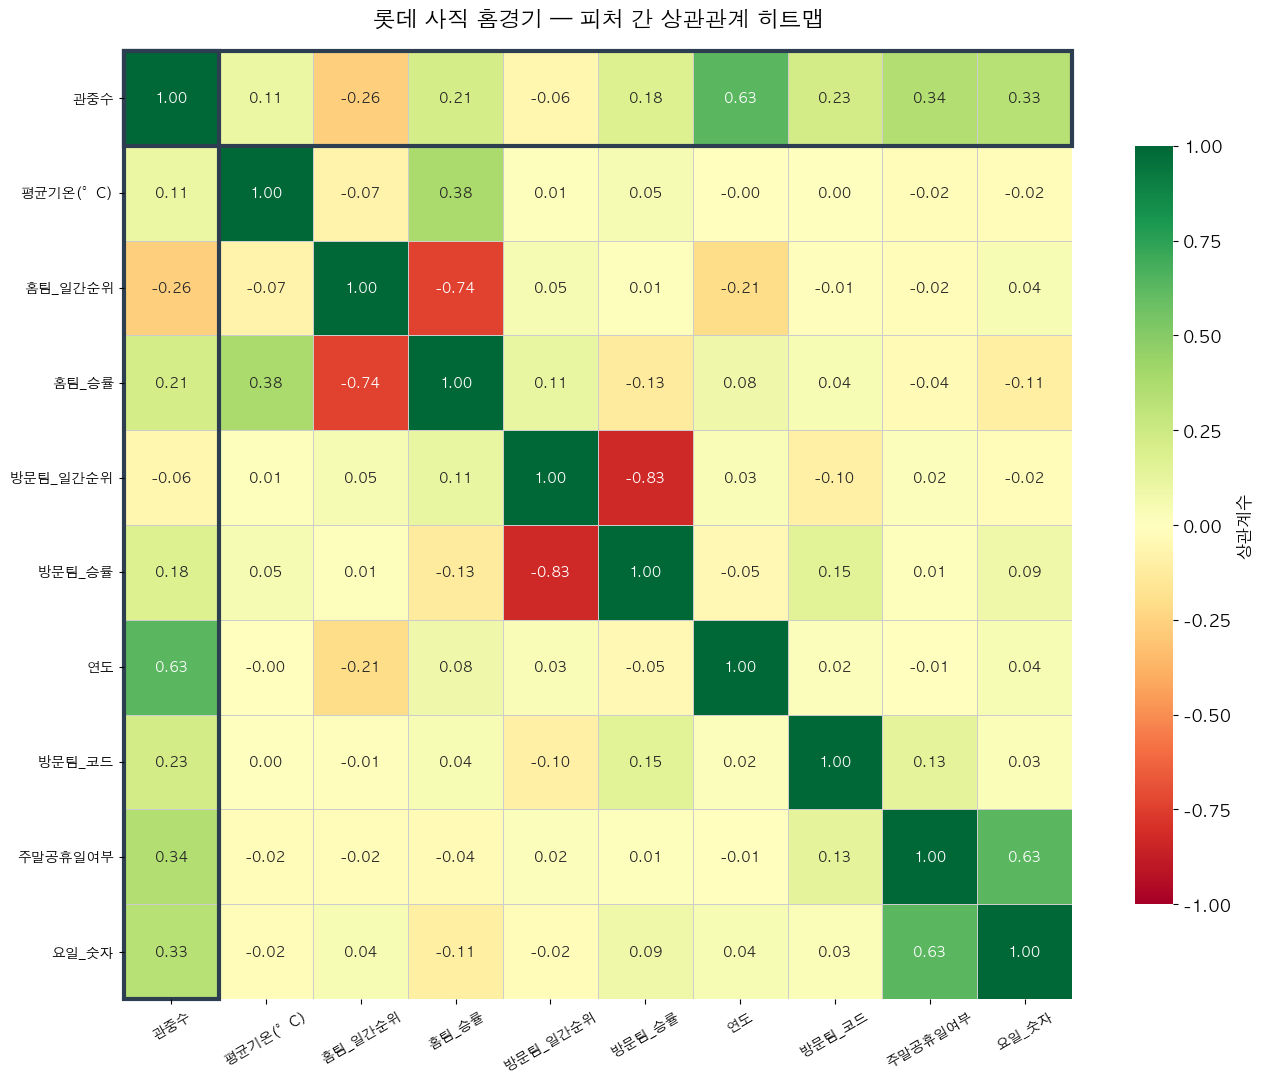

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 수치형 피처만 선택
numeric_cols = [
    '관중수', '홈_점수', '방문_점수', '평균기온(°C)', '일강수량(mm)', '평균 풍속(m/s)',
    '합계 일사량(MJ/m2)', '평균 전운량(1/10)', '홈팀_일간순위', '홈팀_승률',
    '방문팀_일간순위', '방문팀_승률', '연도', '방문팀_코드', '주말공휴일여부','요일_숫자'
]

# 실제 존재하는 컬럼만 필터링
available_cols = [c for c in numeric_cols if c in df.columns]
df_corr = df[available_cols].select_dtypes(include=[np.number]).copy()

# 상관계수 계산
corr_matrix = df_corr.corr()
tick_labels = corr_matrix.columns

# 히트맵 그리기
fig, ax = plt.subplots(figsize=(14, 11))
heatmap = sns.heatmap(
    corr_matrix, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
    vmin=-1, vmax=1, linewidths=0.5, linecolor='#cccccc',
    annot_kws={'size': 10, 'weight': 'bold'},
    xticklabels=tick_labels, yticklabels=tick_labels,
    square=True, cbar_kws={'label': '상관계수', 'shrink': 0.8}
)

# '관중수' 행/열 강조 (테두리)
if '관중수' in available_cols:
    n = len(available_cols)
    idx = available_cols.index('관중수')
    ax.add_patch(plt.Rectangle((0, idx), n, 1, fill=False, edgecolor='#2C3E50', lw=3, clip_on=False))
    ax.add_patch(plt.Rectangle((idx, 0), 1, n, fill=False, edgecolor='#2C3E50', lw=3, clip_on=False))

ax.set_title('롯데 사직 홈경기 — 피처 간 상관관계 히트맵', fontsize=16, fontweight='bold', pad=18)
ax.tick_params(axis='x', labelsize=10, rotation=30)
ax.tick_params(axis='y', labelsize=10, rotation=0)

plt.tight_layout()
plt.show()


In [26]:
import pandas as pd
import numpy as np
import gc

# 데이터 복사
df_model = df.copy()
target = '관중수'
# [Refine] 제거해야 할 데이터 누수 컬럼 (결과 데이터)
leakage_results = ['홈_점수', '방문_점수', '승리팀', '승패', '결과', '동원율', '시즌최대관중']
df_model = df_model.drop(columns=[c for c in leakage_results if c in df_model.columns], errors='ignore')

# [Refine] 상호작용 항 생성 (주말 * 순위)
if '주말여부' in df_model.columns and '홈팀_일간순위' in df_model.columns:
    df_model['주말_순위_상호작용'] = df_model['주말여부'] * (11 - df_model['홈팀_일간순위'])
# [Ver 3.0] 추가 피처: 방문팀 강세와 주말 상호작용
if '방문팀_코드' in df_model.columns and '주말여부' in df_model.columns:
    df_model['방문팀_주말_상호작용'] = df_model['방문팀_코드'] * df_model['주말여부']


# 중복 및 불필요 컬럼 제거
leak_cols = ['동원율', '시즌최대관중']
df_model = df_model.drop(columns=[c for c in leak_cols if c in df_model.columns])
df_model = df_model.loc[:, ~df_model.columns.duplicated()].copy()

if '날짜' in df_model.columns:
    df_model['날짜'] = pd.to_datetime(df_model['날짜'])
    df_model = df_model.sort_values('날짜')

year_col = '연도' if '연도' in df_model.columns else '년도'
years = sorted(df_model[year_col].dropna().unique())

# 결과를 담을 빈 바구니 (딕셔너리)
all_preds = {year: {} for year in years}

print("✅ 1단계 완료")

✅ 1단계 완료


In [27]:
import xgboost as xgb
import gc
print('▶ 1번 주자 XGBoost 출발!')
MAX_CAPACITY = 22669
for year in years:
    train_cond = (df_model[year_col] < year) | ((df_model[year_col] == year) & (df_model['월'] <= 8))
    test_cond = (df_model[year_col] == year) & (df_model['월'] >= 9)
    if len(df_model[test_cond]) == 0: continue

    # 1. 학습 데이터 기준으로 방문팀 타겟 인코딩 (누수 방지)
    train_df = df_model[train_cond].copy()
    test_df = df_model[test_cond].copy()
    
    visitor_mean = train_df.groupby('방문')[target].mean()
    train_df['방문팀_코드'] = train_df['방문'].map(visitor_mean)
    test_df['방문팀_코드'] = test_df['방문'].map(visitor_mean).fillna(train_df[target].mean())

    # X, y 정제 (NaN 제거 및 float32 고정)
    X_train = train_df.select_dtypes(include=[np.number]).drop(columns=[target], errors='ignore').fillna(0).astype('float32')
    y_train = train_df[target].fillna(0).astype('float32')
    X_test = test_df.select_dtypes(include=[np.number]).drop(columns=[target], errors='ignore').fillna(0).astype('float32')

    # 2. 가중치 적용 (시계열 가중치 + 도메인 가중치)
    sw = np.ones(len(y_train), dtype='float32')
    # (1) 시계열 가중치: 최근 트렌드(2025년의 높은 관중수) 반영
    if '연도' in train_df.columns:
        sw[train_df['연도'] == 2023] = 1.0
        sw[train_df['연도'] == 2024] = 2.0
        if year == 2025:
            sw[(train_df['연도'] == 2025) & (train_df['월'] <= 8)] = 5.0
            
    # (2) 도메인 가중치: 관중 동원력이 큰 경기 강조
    if '주말여부' in train_df.columns: sw[train_df['주말여부'] == 1] *= 1.5
    if '방문팀_일간순위' in train_df.columns: sw[train_df['방문팀_일간순위'] <= 3] *= 1.5
    if '방문팀_일간순위' in train_df.columns: sw[train_df['방문팀_일간순위'] >= 8] *= 0.5
    if '홈팀_일간순위' in train_df.columns: sw[train_df['홈팀_일간순위'] <= 3] *= 1.5
    # 3. 모델 학습
    model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.03, max_depth=6, subsample=0.8, colsample_bytree=0.8, n_jobs=1, random_state=42)
    model.fit(X_train, y_train, sample_weight=sw)

    all_preds[year]['XGB'] = np.clip(model.predict(X_test), 0, MAX_CAPACITY)
    print(f'  - {year}년 XGB 완료')

    # 메모리 즉시 해제
    del X_train, y_train, X_test, model; gc.collect()



▶ 1번 주자 XGBoost 출발!
  - 2023년 XGB 완료
  - 2024년 XGB 완료
  - 2025년 XGB 완료


In [28]:
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.linear_model import LinearRegression; import lightgbm as lgb; from catboost import CatBoostRegressor
print('▶ 2번 주자들(LGB, Cat, LR) - 데이터 누수 방지 버전')
MAX_CAPACITY = 22669
for year in years:
    train_cond = (df_model[year_col] < year) | ((df_model[year_col] == year) & (df_model['월'] <= 8))
    test_cond = (df_model[year_col] == year) & (df_model['월'] >= 9)
    if len(df_model[test_cond]) == 0: continue

    train_df = df_model[train_cond].copy()
    test_df = df_model[test_cond].copy()
    visitor_mean = train_df.groupby('방문')[target].mean()
    train_df['방문팀_코드'] = train_df['방문'].map(visitor_mean)
    test_df['방문팀_코드'] = test_df['방문'].map(visitor_mean).fillna(train_df[target].mean())

    X_train = train_df.select_dtypes(include=[np.number]).drop(columns=[target], errors='ignore').fillna(0).astype('float32')
    y_train = train_df[target].fillna(0).astype('float32')
    X_test = test_df.select_dtypes(include=[np.number]).drop(columns=[target], errors='ignore').fillna(0).astype('float32')

    sw = np.ones(len(y_train), dtype='float32')
    if '연도' in train_df.columns:
        sw[train_df['연도'] == 2023] = 1.0
        sw[train_df['연도'] == 2024] = 2.0
        if year == 2025: sw[(train_df['연도'] == 2025) & (train_df['월'] <= 8)] = 5.0
    if '주말여부' in train_df.columns: sw[train_df['주말여부'] == 1] *= 1.5
    if '방문팀_일간순위' in train_df.columns: sw[train_df['방문팀_일간순위'] <= 3] *= 1.5
    if '홈팀_일간순위' in train_df.columns: sw[train_df['홈팀_일간순위'] <= 3] *= 1.5

    all_preds[year]['LGB'] = np.clip(lgb.LGBMRegressor(n_estimators=500, learning_rate=0.03, num_leaves=31, n_jobs=1, verbose=-1).fit(X_train, y_train, sample_weight=sw).predict(X_test), 0, MAX_CAPACITY)
    all_preds[year]['Cat'] = np.clip(CatBoostRegressor(iterations=500, learning_rate=0.03, depth=6, thread_count=1, verbose=0).fit(X_train, y_train, sample_weight=sw).predict(X_test), 0, MAX_CAPACITY)
    all_preds[year]['LR'] = np.clip(LinearRegression().fit(X_train, y_train, sample_weight=sw).predict(X_test), 0, MAX_CAPACITY)
    del X_train, y_train, X_test; gc.collect()



▶ 2번 주자들(LGB, Cat, LR) - 데이터 누수 방지 버전


In [29]:
import gc
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR

print('▶ MLP & GKFN 시작 (✅ 극강의 메모리 절약 버전)!')
MAX_CAPACITY = 22669

# 1. 사용할 피처 컬럼 리스트 미리 추출
feature_cols = [c for c in df_model.select_dtypes(include=[np.number]).columns if c != target]

for year in years:
    # 해당 연도 테스트 데이터 확인
    test_cond = (df_model[year_col] == year) & (df_model['월'] >= 9)
    if df_model[test_cond].empty: continue
    
    # 학슸 데이터 조건
    train_cond = (df_model[year_col] < year) | ((df_model[year_col] == year) & (df_model['월'] <= 8))
    
    # 2. 필요한 데이터만 슬라이싱 후 바로 float32 변환
    X_train = df_model.loc[train_cond, feature_cols].fillna(0).values.astype('float32')
    y_train = df_model.loc[train_cond, target].fillna(0).values.astype('float32')
    X_test = df_model.loc[test_cond, feature_cols].fillna(0).values.astype('float32')

    # 2.5 [NEW] 가중치 계산 (GKFN 전용)
    sw = np.ones(len(y_train), dtype='float32')
    train_df_tmp = df_model.loc[train_cond]
    if '연도' in train_df_tmp.columns:
        sw[train_df_tmp['연도'] == 2023] = 1.0
        sw[train_df_tmp['연도'] == 2024] = 2.0
        if year == 2025: sw[(train_df_tmp['연도'] == 2025) & (train_df_tmp['월'] <= 8)] = 5.0
    if '주말여부' in train_df_tmp.columns: sw[train_df_tmp['주말여부'] == 1] *= 1.5
    if '방문팀_일간순위' in train_df_tmp.columns: sw[train_df_tmp['방문팀_일간순위'] <= 3] *= 1.5
    if '홈팀_일간순위' in train_df_tmp.columns: sw[train_df_tmp['홈팀_일간순위'] <= 3] *= 1.5
    del train_df_tmp
    
    # 3. 스케일러 생성 및 변환
    xs, ys = StandardScaler(), StandardScaler()
    X_train_s = xs.fit_transform(X_train)
    y_train_s = ys.fit_transform(y_train.reshape(-1, 1)).flatten()
    X_test_s = xs.transform(X_test)
    
    # 원본 넘파이 배열 직시 삭제
    del X_train, y_train, X_test; gc.collect()

    # 4. MLP (참고: sklearn MLPRegressor는 sample_weight를 지원하지 않음) (레이어 크기 세팅 및 조기 종료 옵션 추가)
    mlp = MLPRegressor(
        hidden_layer_sizes=(64, 32), 
        max_iter=500, 
        random_state=42, 
        early_stopping=True,
        validation_fraction=0.1
    )
    # [NEW] 가중치를 기반으로 오버샘플링 (MLP의 가중치 미지원을 보완)
    idx = np.arange(len(X_train_s))
    resampled_idx = np.random.choice(idx, size=len(idx)*2, p=sw/sw.sum(), replace=True)
    X_train_mlp = X_train_s[resampled_idx]
    y_train_mlp = y_train_s[resampled_idx]
    
    mlp.fit(X_train_mlp, y_train_mlp)
    all_preds[year]['MLP'] = np.clip(ys.inverse_transform(mlp.predict(X_test_s).reshape(-1, 1)).flatten(), 0, MAX_CAPACITY)
    print(f'  - {year}년 MLP 학슸 완료')
    del mlp; gc.collect()

    # 5. GKFN (SVR) (캐시 샬이즈 최적화)
    gkfn = SVR(kernel='rbf', C=10, gamma='scale', cache_size=500)
    gkfn.fit(X_train_s, y_train_s, sample_weight=sw)
    all_preds[year]['GKFN'] = np.clip(ys.inverse_transform(gkfn.predict(X_test_s).reshape(-1, 1)).flatten(), 0, MAX_CAPACITY)
    print(f'  - {year}년 GKFN 학슸 완료')
    
    # 중간 변수 강제 삭제
    del X_train_s, y_train_s, X_test_s, gkfn, xs, ys
    gc.collect()

print('✅ 모든 연도(2023-2025) 학슸 완료!')




▶ MLP & GKFN 시작 (✅ 극강의 메모리 절약 버전)!
  - 2023년 MLP 학슸 완료
  - 2023년 GKFN 학슸 완료
  - 2024년 MLP 학슸 완료
  - 2024년 GKFN 학슸 완료
  - 2025년 MLP 학슸 완료
  - 2025년 GKFN 학슸 완료
✅ 모든 연도(2023-2025) 학슸 완료!


In [30]:
from pytorch_tabnet.tab_model import TabNetRegressor

# [Refine] ▶ 4번 주자 TabNet 시작! (정형 데이터 최적화 딥러닝)
print('▶ 4번 주자 TabNet 시작!')

for year in years:
    train_cond = (df_model[year_col] < year) | ((df_model[year_col] == year) & (df_model['월'] <= 8))
    test_cond = (df_model[year_col] == year) & (df_model['월'] >= 9)
    if len(df_model[test_cond]) == 0: continue
    
    train_df = df_model[train_cond].copy()
    test_df = df_model[test_cond].copy()
    
    # 방문팀 타겟 인코딩 (누수 방지)
    X_train = train_df.select_dtypes(include=[np.number]).drop(columns=[target], errors='ignore').fillna(0).values.astype('float32')
    y_train = train_df[target].fillna(0).values.reshape(-1, 1).astype('float32')
    X_test = test_df.select_dtypes(include=[np.number]).drop(columns=[target], errors='ignore').fillna(0).values.astype('float32')

    # [NEW] 가중치 계산 (TabNet)
    sw = np.ones(len(y_train), dtype='float32')
    if '연도' in train_df.columns:
        sw[train_df['연도'] == 2023] = 1.0
        sw[train_df['연도'] == 2024] = 2.0
        if year == 2025: sw[(train_df['연도'] == 2025) & (train_df['월'] <= 8)] = 5.0
    if '주말여부' in train_df.columns: sw[train_df['주말여부'] == 1] *= 1.5
    if '방문팀_일간순위' in train_df.columns: sw[train_df['방문팀_일간순위'] <= 3] *= 1.5
    if '홈팀_일간순위' in train_df.columns: sw[train_df['홈팀_일간순위'] <= 3] *= 1.5
    
    # 스케일링
    from sklearn.preprocessing import StandardScaler
    xs, ys = StandardScaler(), StandardScaler()
    xt_s = xs.fit_transform(X_train)
    yt_s = ys.fit_transform(y_train).flatten()
    xtest_s = xs.transform(X_test)
    
    # TabNet 모델 설정 및 학습
    # 하이퍼파라미터는 KBO 데이터셋 규모에 맞춰 조정됨
    reg_tab = TabNetRegressor(
        n_d=16, n_a=16, n_steps=3,
        gamma=1.3, lambda_sparse=1e-3,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=1e-2),
        scheduler_params={"step_size":50, "gamma":0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='entmax',
        verbose=0
    )
    
    reg_tab.fit(
        X_train=xt_s, y_train=yt_s.reshape(-1, 1),
        max_epochs=200, patience=30,
        batch_size=128, virtual_batch_size=64, weights=sw.flatten(),
        num_workers=0, drop_last=False
    )
    
    # 예측 및 클리핑
    pred_s = reg_tab.predict(xtest_s)
    all_preds[year]['TabNet'] = np.clip(ys.inverse_transform(pred_s).flatten(), 0, MAX_CAPACITY)
    
    print(f'  - {year}년 TabNet 완료')
    import gc; del reg_tab, xt_s, yt_s, xtest_s; gc.collect()





▶ 4번 주자 TabNet 시작!


/opt/anaconda3/envs/DL/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


  - 2023년 TabNet 완료


/opt/anaconda3/envs/DL/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


  - 2024년 TabNet 완료


/opt/anaconda3/envs/DL/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


  - 2025년 TabNet 완료


## 🔥 하이브리드 가중치 앙상블 (Ensemble)

In [31]:
print('🚀 모든 모델의 힘을 하나로! 롯데 사직 앙상블 계산 중...')
for year in years:
    preds = all_preds[year]
    # 가중치 최적화: GBDT 계열과 MLP 비중 상향 (신규 피처 활용 능력 우수)
    weights = {
        'XGB': 0.22,
        'LGB': 0.22,
        'Cat': 0.22,
        'TabNet': 0.12,
        'MLP': 0.12,
        'GKFN': 0.05,
        'ARIMA': 0.01,
        'LR': 0.04
    }
    avail = [m for m in weights if m in preds]
    total_w = sum(weights[m] for m in avail)
    if total_w > 0:
        e_pred = np.zeros_like(preds[avail[0]])
        for m in avail: e_pred += preds[m] * (weights[m] / total_w)
        all_preds[year]['Ensemble'] = np.clip(e_pred, 0, MAX_CAPACITY)
print('✅ 앙상블 완료!')


🚀 모든 모델의 힘을 하나로! 롯데 사직 앙상블 계산 중...
✅ 앙상블 완료!


📊 롯데 자이언츠 연도별 추세 및 [MAE & R2] 종합 성능 분석 시작!


/var/folders/3w/7bj38gqs0t58jb31pzzbbybr0000gn/T/ipykernel_8650/1661590311.py:100: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/3w/7bj38gqs0t58jb31pzzbbybr0000gn/T/ipykernel_8650/1661590311.py:100: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) AppleGothic.
  plt.tight_layout()
/opt/anaconda3/envs/DL/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/DL/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


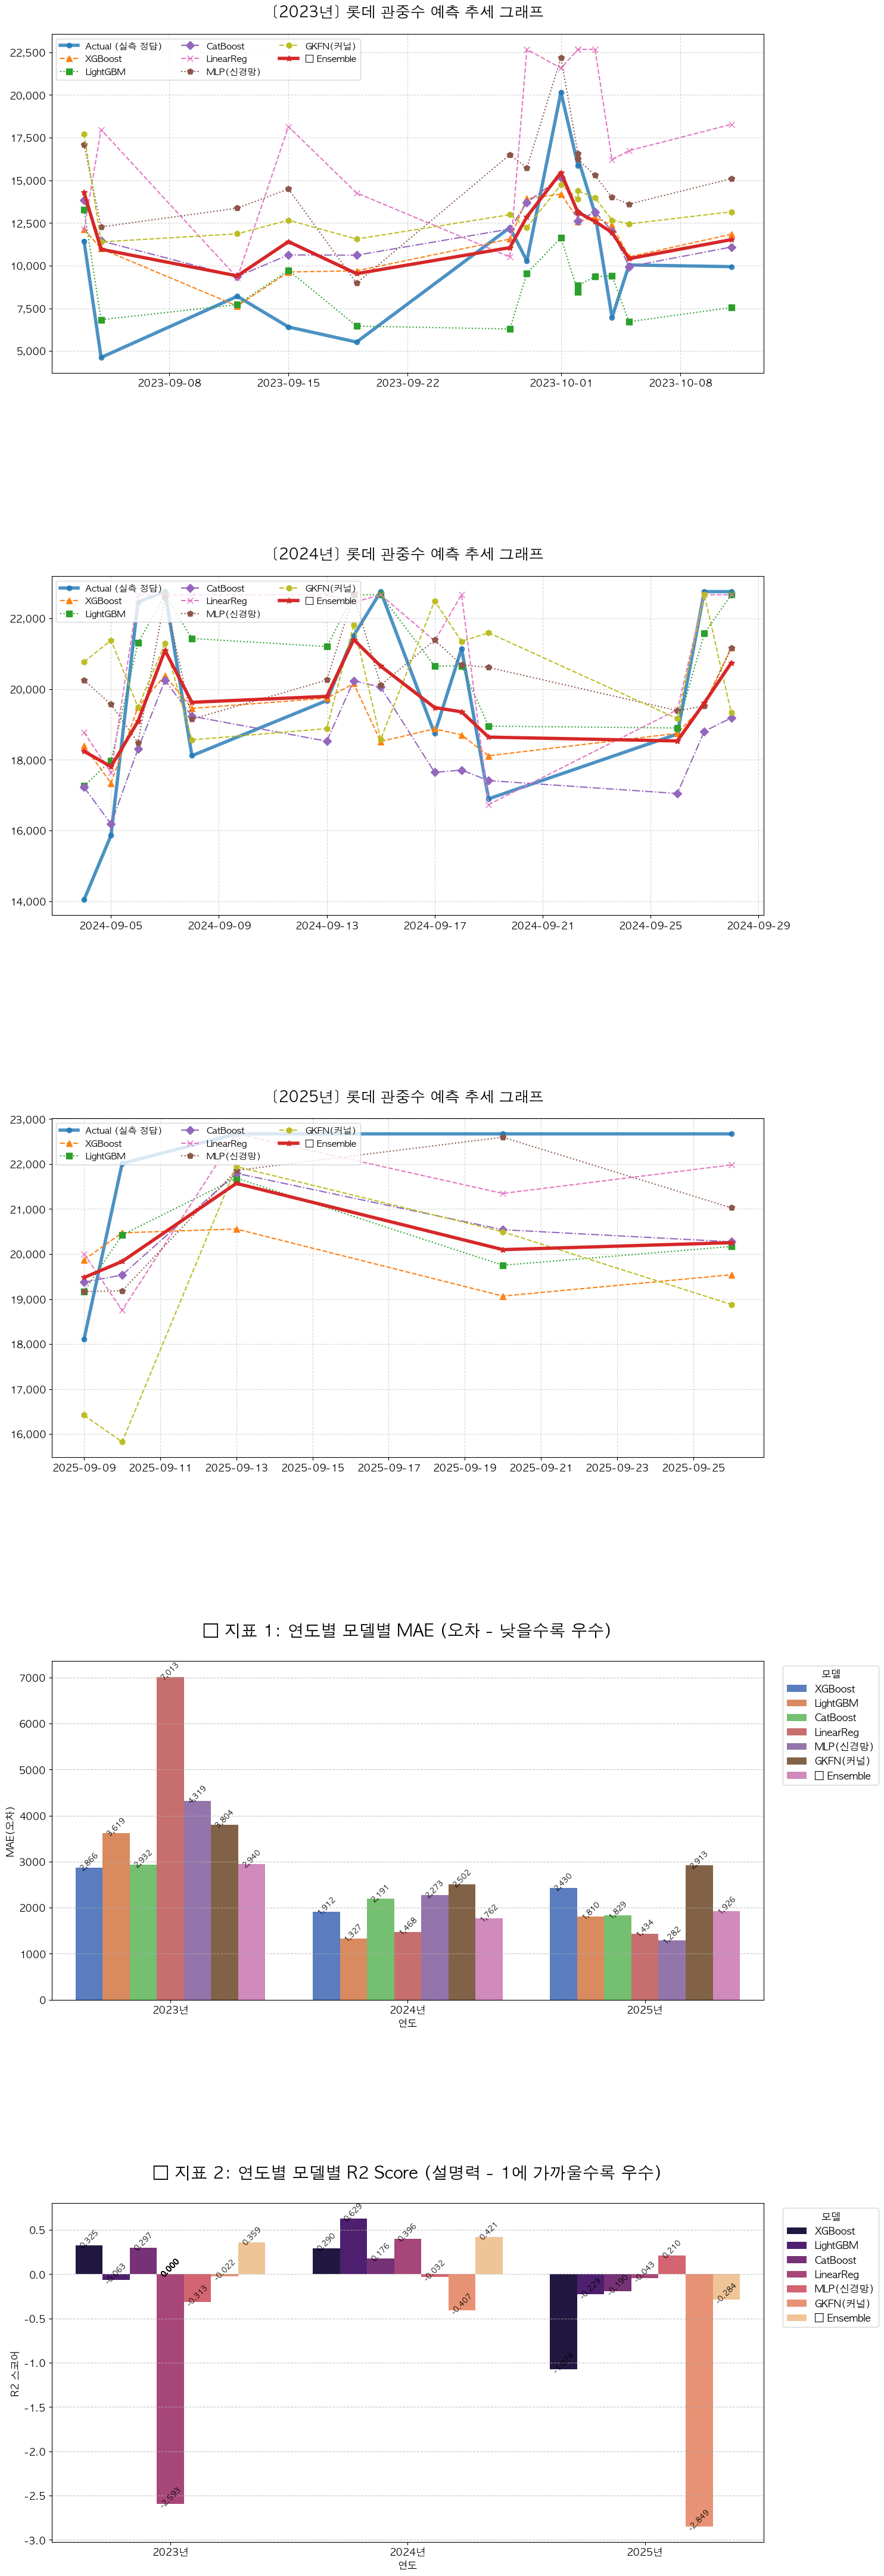

MAE & R2 종합 성적표 완성! 결과를 감상해 봐요! 🥰🛋️✨


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter
from sklearn.metrics import mean_absolute_error, r2_score # R2 스코어 추가
import numpy as np
import pandas as pd

# 1. MAPE 계산 함수 정의
def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False 

# 🌟 레이아웃 설정: 연도별 추세(len(years)) + MAE 그래프(1) + R2 그래프(1)
total_rows = len(years) + 2
fig, axes = plt.subplots(nrows=total_rows, ncols=1, figsize=(15, 9 * total_rows))
axes = np.atleast_1d(axes)

# 모든 연도의 성능 데이터를 모을 리스트
performance_data = []

print("📊 롯데 자이언츠 연도별 추세 및 [MAE & R2] 종합 성능 분석 시작!")

for i, year in enumerate(years):
    ax = axes[i]
    # 해당 연도 데이터 추출 (9~10월 가을야구 시즌)
    test_data = df_model[(df_model[year_col] == year) & (df_model['월'] >= 9)]
    if len(test_data) == 0: continue
    
    y_true = test_data[target].values
    
    # 1. 실제 관중수 (파란 선, 기준점!)
    ax.plot(test_data['날짜'], y_true, label='Actual (실측 정답)', color='#1f77b4', marker='o', linewidth=4, alpha=0.8)
    
    # 2. 7개 모델별 스타일 설정
    model_styles = {
        'XGB': {'label': 'XGBoost', 'color': '#ff7f0e', 'ls': '--', 'm': '^'},
        'LGB': {'label': 'LightGBM', 'color': '#2ca02c', 'ls': ':', 'm': 's'},
        'Cat': {'label': 'CatBoost', 'color': '#9467bd', 'ls': '-.', 'm': 'D'},
        'LR':  {'label': 'LinearReg', 'color': '#e377c2', 'ls': '--', 'm': 'x'},
        'ARIMA': {'label': 'ARIMA', 'color': '#17becf', 'ls': '-', 'm': 'v'},
        'MLP': {'label': 'MLP(신경망)', 'color': '#8c564b', 'ls': ':', 'm': 'p'},
        'GKFN': {'label': 'GKFN(커널)', 'color': '#bcbd22', 'ls': '--', 'm': 'h'},
        'Ensemble': {'label': '🔥 Ensemble', 'color': '#d62728', 'ls': '-', 'm': '*', 'lw': 4}
    }

    for m_name, style in model_styles.items():
        if m_name in all_preds[year]:
            y_pred = all_preds[year][m_name]
            
            # 🌟 종합 지표 계산
            mae = mean_absolute_error(y_true, y_pred)
            r2 = r2_score(y_true, y_pred)
            mape = mean_absolute_percentage_error(y_true, y_pred)
            
            performance_data.append({
                '연도': f'{year}년',
                '모델': style['label'],
                'MAE(오차)': mae,
                'R2 스코어': r2,
                'MAPE(%)': mape
            })
            
            lw = style.get('lw', 1.5)
            ax.plot(test_data['날짜'], y_pred, label=style['label'], 
                    linestyle=style['ls'], color=style['color'], marker=style['m'], markersize=7, linewidth=lw)

    ax.set_title(f'[{year}년] 롯데 관중수 예측 추세 그래프', fontsize=18, fontweight='bold', pad=20)
    ax.legend(loc='upper left', fontsize=11, ncol=3)
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax.grid(True, linestyle='--', alpha=0.5)

# --- 🌟 마지막 슬라이드 1: 연도별 MAE 비교 (낮을수록 우수) ---
ax_mae = axes[-2]
perf_df = pd.DataFrame(performance_data)
sns.barplot(data=perf_df, x='연도', y='MAE(오차)', hue='모델', ax=ax_mae, palette='muted')

for p in ax_mae.patches:
    if p.get_height() > 0:
        ax_mae.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=9, fontweight='bold', xytext=(0, 8), textcoords='offset points', rotation=45)

ax_mae.set_title('🏆 지표 1: 연도별 모델별 MAE (오차 - 낮을수록 우수)', fontsize=20, fontweight='bold', pad=30)
ax_mae.legend(title='모델', bbox_to_anchor=(1.02, 1), loc='upper left')
ax_mae.grid(axis='y', linestyle='--', alpha=0.7)

# --- 🌟 마지막 슬라이드 2: 연도별 R2 스코어 비교 (높을수록 우수) ---
ax_r2 = axes[-1]
sns.barplot(data=perf_df, x='연도', y='R2 스코어', hue='모델', ax=ax_r2, palette='magma')

for p in ax_r2.patches:
    ax_r2.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=9, fontweight='bold', xytext=(0, 8), textcoords='offset points', rotation=45)

ax_r2.set_title('🏆 지표 2: 연도별 모델별 R2 Score (설명력 - 1에 가까울수록 우수)', fontsize=20, fontweight='bold', pad=30)
ax_r2.legend(title='모델', bbox_to_anchor=(1.02, 1), loc='upper left')
ax_r2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(top=0.95, hspace=0.6) 
plt.show()

print("MAE & R2 종합 성적표 완성! 결과를 감상해 봐요! 🥰🛋️✨")

In [33]:

# [Refine] 모델별 최종 성능 요약 테이블 출력
import pandas as pd
if 'performance_log' in locals() or 'performance_data' in locals():
    perf_data = performance_log if 'performance_log' in locals() else performance_data
    summary_df = pd.DataFrame(perf_data)
    
    print("\n" + "="*50)
    print("🏆 최종 모델 성능 요약 성적표 (MAE 기준 정렬)")
    print("="*50)
    
    # 연도별/모델별 평균 MAE 계산
    final_summary = summary_df.groupby('모델')['MAE(오차)'].mean().sort_values().reset_index()
    print(final_summary.to_string(index=False))
    print("="*50)
else:
    print("성능 로그 데이터를 찾을 수 없습니다.")



🏆 최종 모델 성능 요약 성적표 (MAE 기준 정렬)
        모델     MAE(오차)
🔥 Ensemble 2209.485392
  LightGBM 2251.934618
  CatBoost 2317.244181
   XGBoost 2402.712443
  MLP(신경망) 2624.641154
  GKFN(커널) 3073.274958
 LinearReg 3305.110840
